# 1. Data Overview

### 1.1 Data Loading


In [1]:
import pandas as pd

df = pd.read_csv("/content/Hospital_Dataset_2020_2024.csv")

df["admission_date"] = pd.to_datetime(df["admission_date"])

df.head()

,admission_date,hospital_name,admission_count,condition_type,patient_age_group,patient_gender,readmission_count,severity_level,length_of_stay_avg,seasonal_indicator,comorbid_conditions_count,primary_diagnosis_code,daily_medication_dosage,emergency_visit_count
0,2020-01-01 00:00:00,Mecca City Hospital,1,Asthma,46-65,Female,0,Moderate,2.781828,Winter,1,Other,17.455517,2
1,2020-01-01 01:00:00,Dammam General Hospital,2,Asthma,0-17,Female,1,Mild,4.141432,Winter,0,Other,15.099498,3
2,2020-01-01 02:00:00,Mecca City Hospital,1,Asthma,46-65,Female,1,Moderate,8.507026,Winter,2,I21,23.087843,3
3,2020-01-01 03:00:00,Medina Specialist Hospital,3,Asthma,46-65,Male,0,Mild,4.622657,Winter,3,J45,25.247579,2
4,2020-01-01 04:00:00,Medina Specialist Hospital,5,COPD,18-45,Female,2,Moderate,5.818385,Winter,3,J45,18.255290,1


### 1.2 Data Summary


In [2]:
print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Info:")
print(df.info())


Dataset Shape:
(41544, 14)

Column Names:
Index(['admission_date', 'hospital_name', 'admission_count', 'condition_type',
       'patient_age_group', 'patient_gender', 'readmission_count',
       'severity_level', 'length_of_stay_avg', 'seasonal_indicator',
       'comorbid_conditions_count', 'primary_diagnosis_code',
       'daily_medication_dosage', 'emergency_visit_count'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41544 entries, 0 to 41543
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   admission_date             41544 non-null  datetime64[ns]
 1   hospital_name              41544 non-null  object        
 2   admission_count            41544 non-null  int64         
 3   condition_type             41544 non-null  object        
 4   patient_age_group          41544 non-null  object        
 5   patient_gender             4

### 1.3 Statistical Description

In [3]:
print("\nStatistical Description:")
print(df.describe())


Statistical Description:
            admission_date  admission_count  readmission_count  \
count                41544     41544.000000       41544.000000   
mean   2022-05-15 11:30:00         2.000963           0.498435   
min    2020-01-01 00:00:00         0.000000           0.000000   
25%    2021-03-08 17:45:00         1.000000           0.000000   
50%    2022-05-15 11:30:00         2.000000           0.000000   
75%    2023-07-22 05:15:00         3.000000           1.000000   
max    2024-09-26 23:00:00        10.000000           5.000000   
std                    NaN         1.417342           0.708508   

       length_of_stay_avg  comorbid_conditions_count  daily_medication_dosage  \
count        41544.000000               41544.000000             41544.000000   
mean             4.993438                   2.004357                20.019090   
min              1.000000                   0.000000                 5.000000   
25%              3.963454                   1.000000   

# 2. 1st Pre-processing

### 2.1 Check missing values

In [4]:
# 7.3 Check missing values
#Check missing values per column
print("\nMissing Values Per Column:")
print(df.isnull().sum())

# Total missing values in dataset
print("\nTotal Missing Values in Dataset:")
print(df.isnull().sum().sum())


Missing Values Per Column:
admission_date               0
hospital_name                0
admission_count              0
condition_type               0
patient_age_group            0
patient_gender               0
readmission_count            0
severity_level               0
length_of_stay_avg           0
seasonal_indicator           0
comorbid_conditions_count    0
primary_diagnosis_code       0
daily_medication_dosage      0
emergency_visit_count        0
dtype: int64

Total Missing Values in Dataset:
0


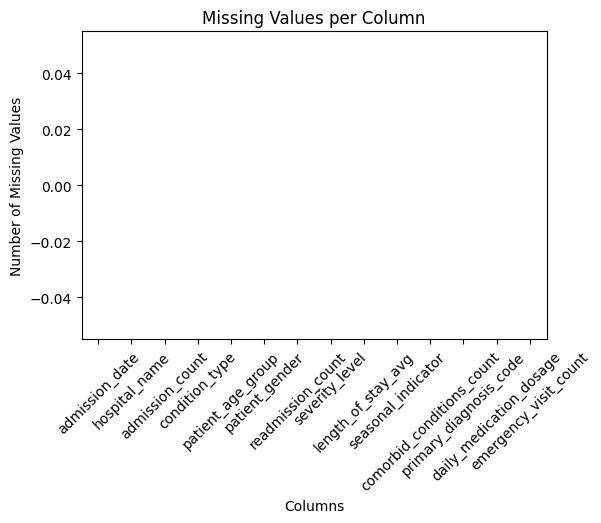

In [5]:
import matplotlib.pyplot as plt

# Calculate missing values per column
missing_values = df.isnull().sum()

# Plot bar chart
plt.figure(figsize=(6,4))
missing_values.plot(kind='bar')

plt.title("Missing Values per Column")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")

plt.xticks(rotation=45)
plt.show()

### 2.2 Handle Missing Values & Remove Duplicates Values

In [6]:
# Handle Missing Values
df.dropna(inplace=True)
print("Dataset shape after dropping missing values:", df.shape)

# Remove Duplicates
print("Dataset shape before removing duplicates:", df.shape)

duplicate_rows = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_rows)

df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after dropping missing values: (41544, 14)
Dataset shape before removing duplicates: (41544, 14)
Number of duplicate rows: 0
Dataset shape after removing duplicates: (41544, 14)


### 2.3 Feature Engineering

In [7]:
# Feature 1: Admission Month
df["admission_month"] = df["admission_date"].dt.month

# Feature 2: Admission Year
df['admission_year'] = df['admission_date'].dt.year

# Feature 3: Patient Risk Score
df["patient_risk_score"] = (
    df["comorbid_conditions_count"] +
    df["emergency_visit_count"] +
    df["readmission_count"]
)

In [8]:
df["hospital_name"].unique()

array(['Mecca City Hospital', 'Dammam General Hospital',
       'Medina Specialist Hospital', 'Dammam Central Hospital',
       'King Saud Hospital', 'Jeddah National Hospital',
       'Riyadh National Hospital', 'Riyadh General Hospital'],
      dtype=object)

In [9]:
# Feature 4: hospital_city
hospital_city_map = {
    "Dammam Central Hospital": "Dammam",
    "Dammam General Hospital": "Dammam",
    "Jeddah National Hospital": "Jeddah",
    "King Saud Hospital": "Riyadh",
    "Mecca City Hospital": "Mecca",
    "Medina Specialist Hospital": "Medina",
    "Riyadh General Hospital": "Riyadh",
    "Riyadh National Hospital": "Riyadh"
}

df["hospital_city"] = df["hospital_name"].map(hospital_city_map)

### 2.4 Review the updated features

In [10]:
print(df[["hospital_name", "hospital_city"]].head(10))

                hospital_name hospital_city
0         Mecca City Hospital         Mecca
1     Dammam General Hospital        Dammam
2         Mecca City Hospital         Mecca
3  Medina Specialist Hospital        Medina
4  Medina Specialist Hospital        Medina
5     Dammam Central Hospital        Dammam
6          King Saud Hospital        Riyadh
7  Medina Specialist Hospital        Medina
8    Jeddah National Hospital        Jeddah
9          King Saud Hospital        Riyadh


In [11]:
print("\nColumn Names:")
print(df.columns)


Column Names:
Index(['admission_date', 'hospital_name', 'admission_count', 'condition_type',
       'patient_age_group', 'patient_gender', 'readmission_count',
       'severity_level', 'length_of_stay_avg', 'seasonal_indicator',
       'comorbid_conditions_count', 'primary_diagnosis_code',
       'daily_medication_dosage', 'emergency_visit_count', 'admission_month',
       'admission_year', 'patient_risk_score', 'hospital_city'],
      dtype='object')


# 3. Initial Analysis Phase (EDA)

### 3.1 Imbalanced Visualization

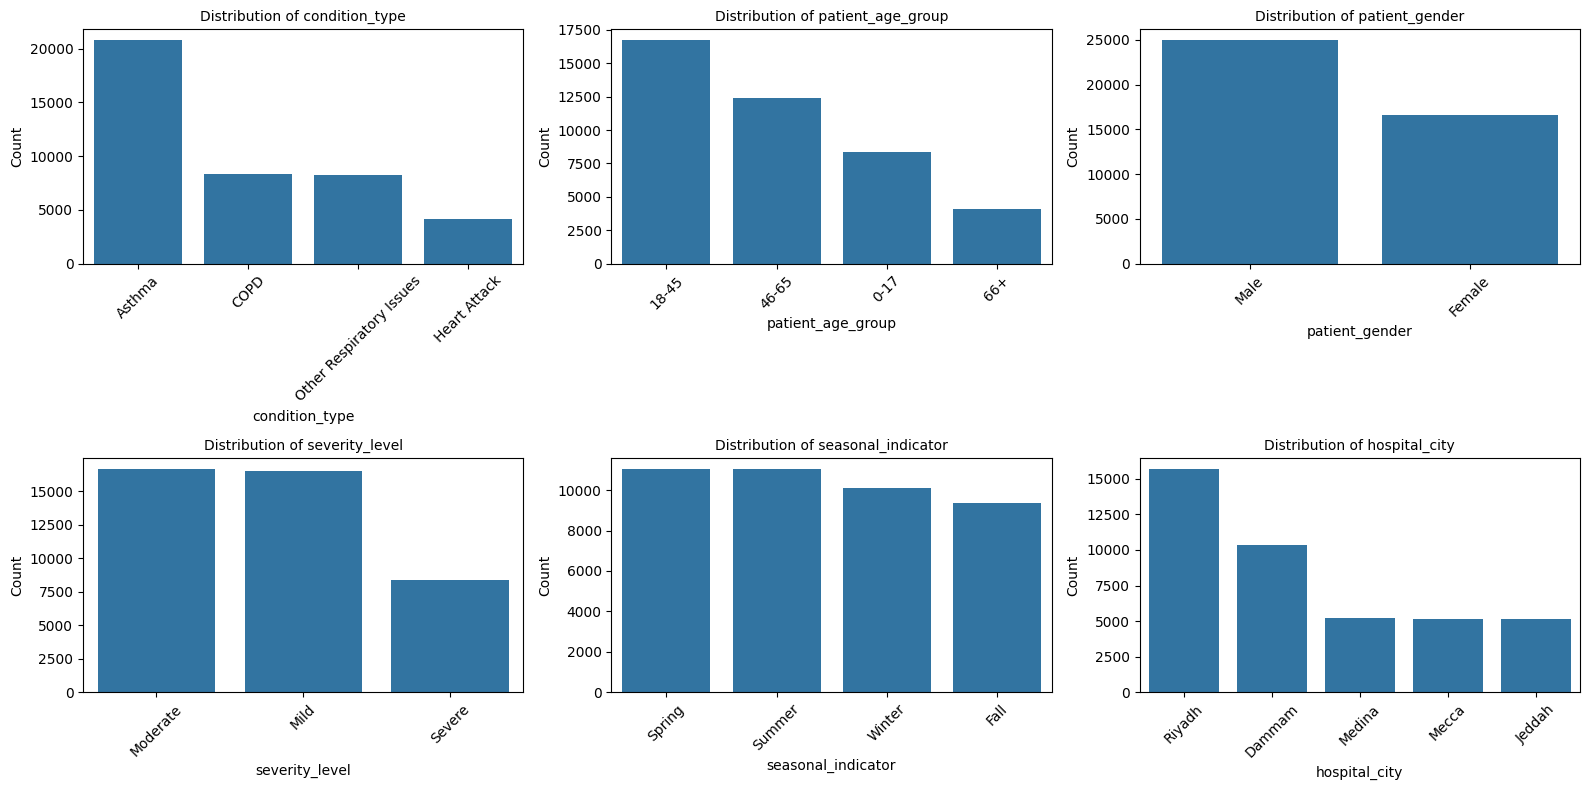

In [12]:
import seaborn as sns
# To ensure this visualization always uses unencoded categorical values,

categorical_cols = [
    'condition_type',
    'patient_age_group',
    'patient_gender',
    'severity_level',
    'seasonal_indicator',
    'hospital_city'
]

plt.figure(figsize=(16, 8))

for i, col in enumerate(categorical_cols, 1):
    plt.subplot(2, 3, i)
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order)
    plt.title(f'Distribution of {col}', fontsize=10)
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### 3.2 Comparison of Admission Counts by Season and Condition Type


Value counts for 'admission_month' after type conversion:
admission_month
1     3720
2     3408
3     3720
4     3600
5     3720
6     3600
7     3720
8     3720
9     3504
10    2976
11    2880
12    2976
Name: count, dtype: int64

'admission_month' dtype after conversion: int64


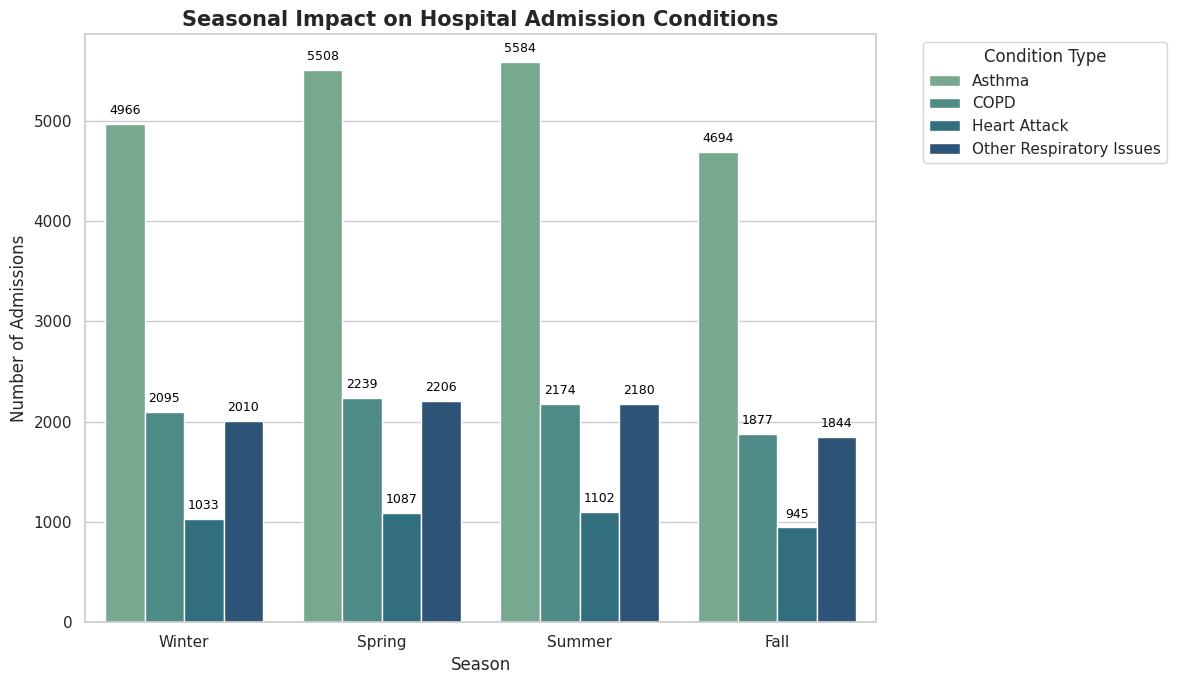

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Ensure admission_month is integer type and verify its distribution
df['admission_month'] = df['admission_month'].astype(int)
print("\nValue counts for 'admission_month' after type conversion:")
print(df['admission_month'].value_counts().sort_index())
print("\n'admission_month' dtype after conversion:", df['admission_month'].dtype)


# 2. Set the visualization style
sns.set_theme(style="whitegrid")


# 3. Define the correct order of seasons
season_order = ['Winter', 'Spring', 'Summer', 'Fall']


# 4. Create the count plot to show admissions by season and condition
plt.figure(figsize=(12, 7))
ax = sns.countplot(data=df, x='seasonal_indicator', hue='condition_type', order=season_order, palette='crest')


# 5. Add the title and axis labels
plt.title('Seasonal Impact on Hospital Admission Conditions', fontsize=15, fontweight='bold')
plt.xlabel('Season', fontsize=12)
plt.ylabel('Number of Admissions', fontsize=12)


# 6. Adjust legend position for better readability
plt.legend(title='Condition Type', bbox_to_anchor=(1.05, 1), loc='upper left')


# 7. Add value labels above each bar
for p in ax.patches:

  if p.get_height() > 0:
    ax.annotate(f'{int(p.get_height())}',
    (p.get_x() + p.get_width() / 2., p.get_height()),
    ha='center', va='bottom',
    fontsize=9, color='black',
    xytext=(0, 5),
    textcoords='offset points')


# 8. Adjust layout to prevent overlapping
plt.tight_layout()

# 9. Display the plot
plt.show()

### 3.3 Comparison of Hospital Admission Counts by Age and Gender

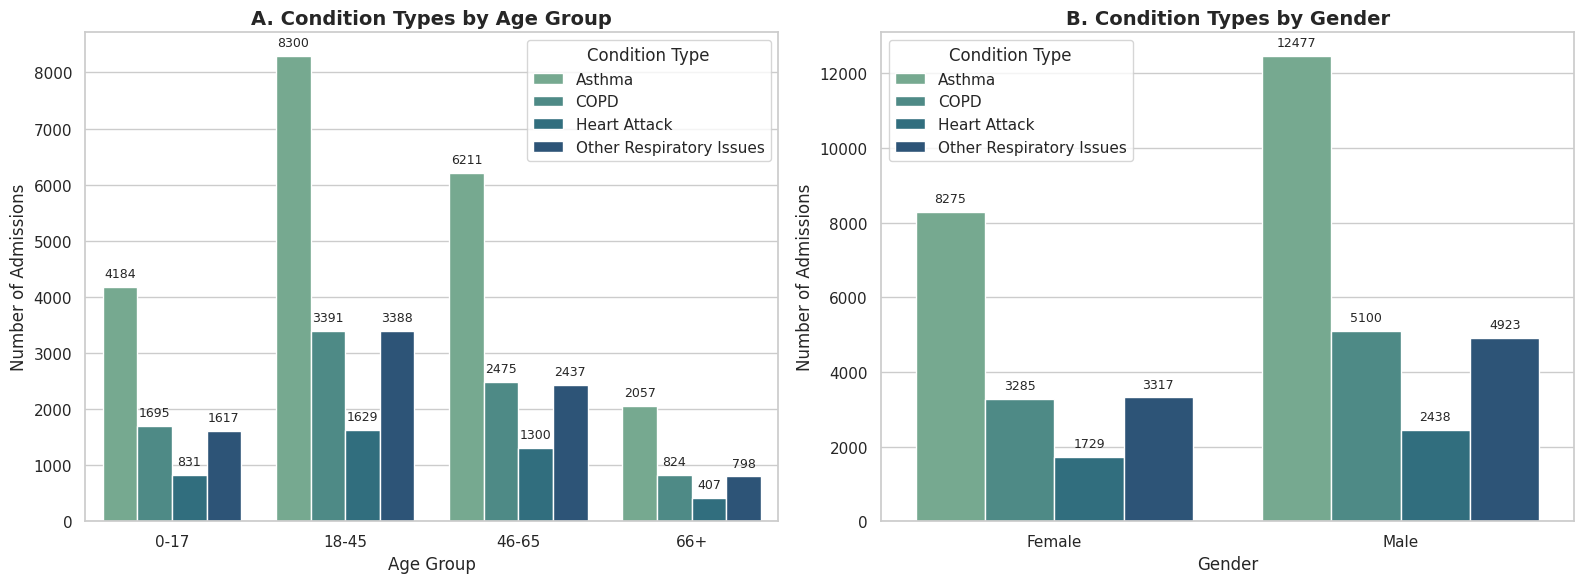

In [14]:
# 1. Create a figure with two subplots side-by-side (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Chart A: Condition Type by Age Group ---
age_order = ['0-17', '18-45', '46-65', '66+']
sns.countplot(ax=axes[0], data=df, x='patient_age_group', hue='condition_type', order=age_order, palette='crest')
axes[0].set_title('A. Condition Types by Age Group', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Age Group', fontsize=12)
axes[0].set_ylabel('Number of Admissions', fontsize=12)
axes[0].legend(title='Condition Type')

# Add numbers on top of bars for Chart A
for p in axes[0].patches:
    if p.get_height() > 0:
        axes[0].annotate(f'{int(p.get_height())}',
                         (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='bottom', fontsize=9, xytext=(0, 5), textcoords='offset points')

# --- Chart B: Condition Type by Gender ---
# Note: If 'patient_gender' was already encoded (e.g., 0/1) in a previous section
# and those cells were run, this plot might display 0/1 instead of 'Female'/'Male'.
# Ensure relevant preprocessing cells are run in the correct order.
sns.countplot(ax=axes[1], data=df, x='patient_gender', hue='condition_type', palette='crest')
axes[1].set_title('B. Condition Types by Gender', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Gender', fontsize=12)
axes[1].set_ylabel('Number of Admissions', fontsize=12)
axes[1].legend(title='Condition Type')

# Add numbers on top of bars for Chart B
for p in axes[1].patches:
    if p.get_height() > 0:
        axes[1].annotate(f'{int(p.get_height())}',
                         (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='bottom', fontsize=9, xytext=(0, 5), textcoords='offset points')

# 2. Final layout adjustment
plt.tight_layout()
plt.show()

### 3.4 Comparison of Admission Counts by City

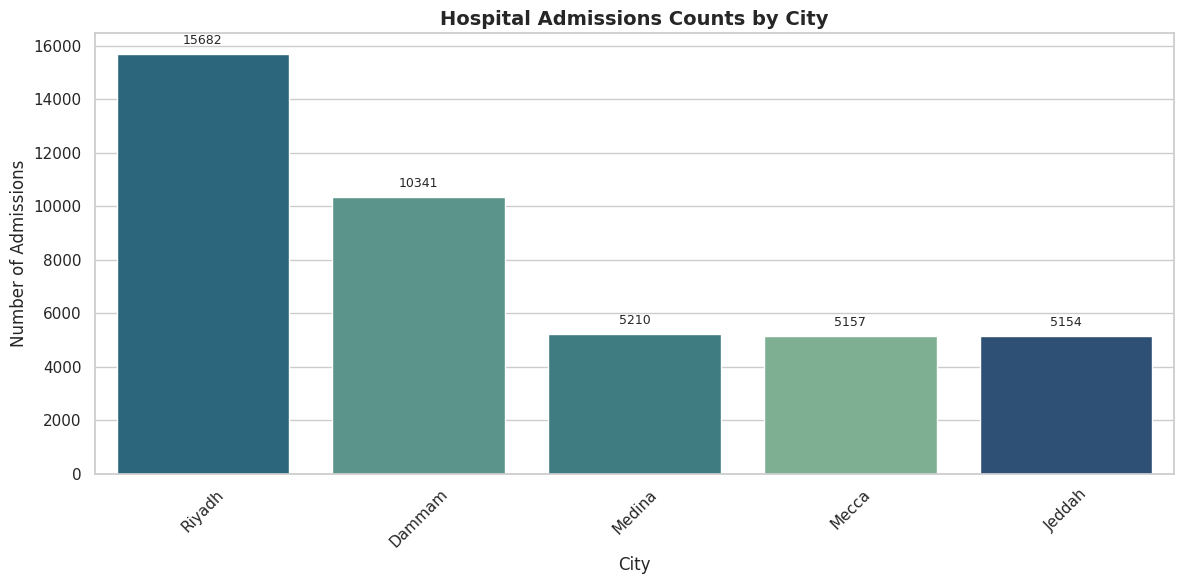

In [15]:
# 1. Get the order of cities from highest admissions to lowest
city_order = df['hospital_city'].value_counts().index

# 2. Create the plot for Hospital Capacity by City
plt.figure(figsize=(12, 6))
ax = sns.countplot(data=df, x='hospital_city', hue='hospital_city', order=city_order, palette='crest', legend=False)

# 3. Add titles and labels
plt.title('Hospital Admissions Counts by City', fontsize=14, fontweight='bold')
plt.xlabel('City', fontsize=12)
plt.ylabel('Number of Admissions', fontsize=12)

# 4. Add data labels on top of bars
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{int(p.get_height())}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=9, xytext=(0, 5), textcoords='offset points')

# 5. Rotate city names just in case they are long
plt.xticks(rotation=45)

# 6. Final layout adjustment
plt.tight_layout()
plt.show()

### 3.5 Monthly Admission Trends Analysis

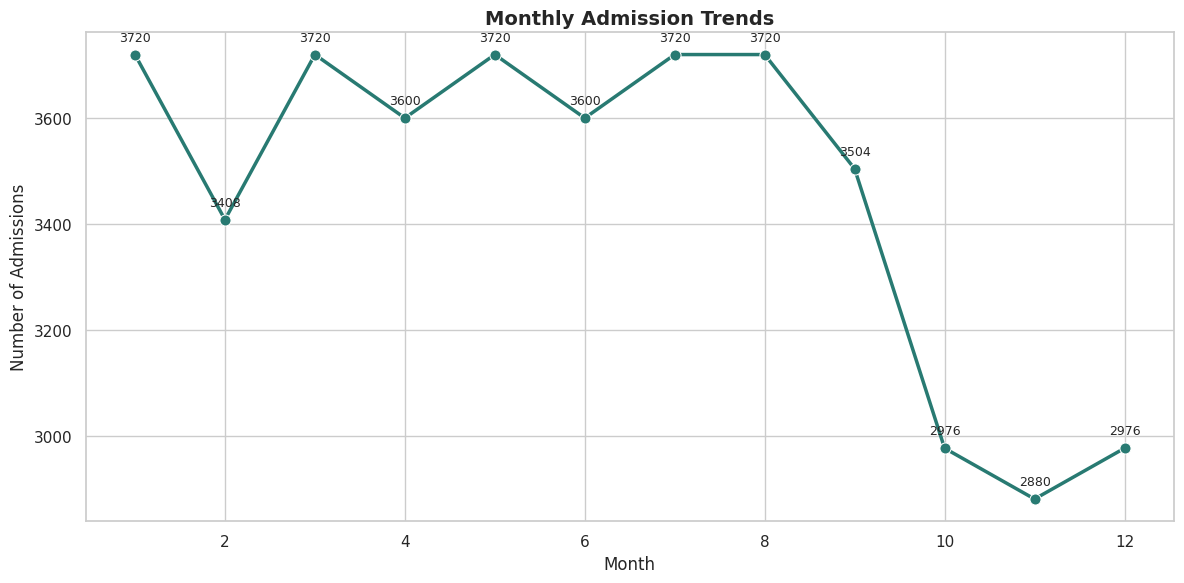

In [16]:
# 1. Calculate the number of admissions per month
monthly_counts = df.groupby('admission_month').size().reset_index(name='Admissions')

# 2. Create the Line Chart
plt.figure(figsize=(12, 6))
ax = sns.lineplot(data=monthly_counts, x='admission_month', y='Admissions',
                  marker='o', markersize=8, color='#287a72', linewidth=2.5)

# 3. Add titles and labels
plt.title('Monthly Admission Trends', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Admissions', fontsize=12)

# 4. Add data labels on top of each point on the line
for x, y in zip(monthly_counts['admission_month'], monthly_counts['Admissions']):
    ax.annotate(f'{int(y)}',
                (x, y),
                textcoords="offset points",
                xytext=(0,10),
                ha='center', fontsize=9)

# 5. Final layout adjustment
plt.tight_layout()
plt.show()

### 3.6 Analysis of the Relationship Between Comorbid Conditions and Patient Risk Score

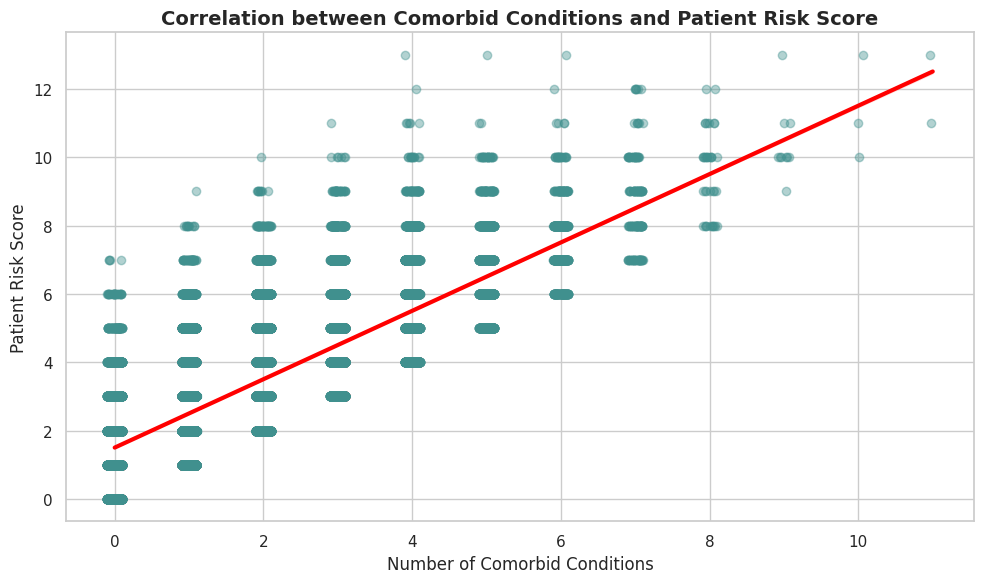

In [17]:
# 1. Create the Scatter plot with a Regression line
plt.figure(figsize=(10, 6))

main_color = sns.color_palette("crest")[2]

sns.regplot(
    data=df,
    x='comorbid_conditions_count',
    y='patient_risk_score',
    scatter_kws={'alpha':0.4, 'color': main_color},
    line_kws={'color': 'red', 'linewidth': 3},
    x_jitter=0.1
)

# Note: patient_risk_score is an engineered feature derived from comorbid_conditions_count,
# emergency_visit_count, and readmission_count. The strong correlation observed here
# is a result of this engineering, not a newly discovered relationship.

# 2. Add titles and labels
plt.title('Correlation between Comorbid Conditions and Patient Risk Score',
          fontsize=14, fontweight='bold')
plt.xlabel('Number of Comorbid Conditions', fontsize=12)
plt.ylabel('Patient Risk Score', fontsize=12)

# 3. Final layout adjustment
plt.tight_layout()
plt.show()

### 3.7 Analysis of Patient Risk Score Across Readmission Levels

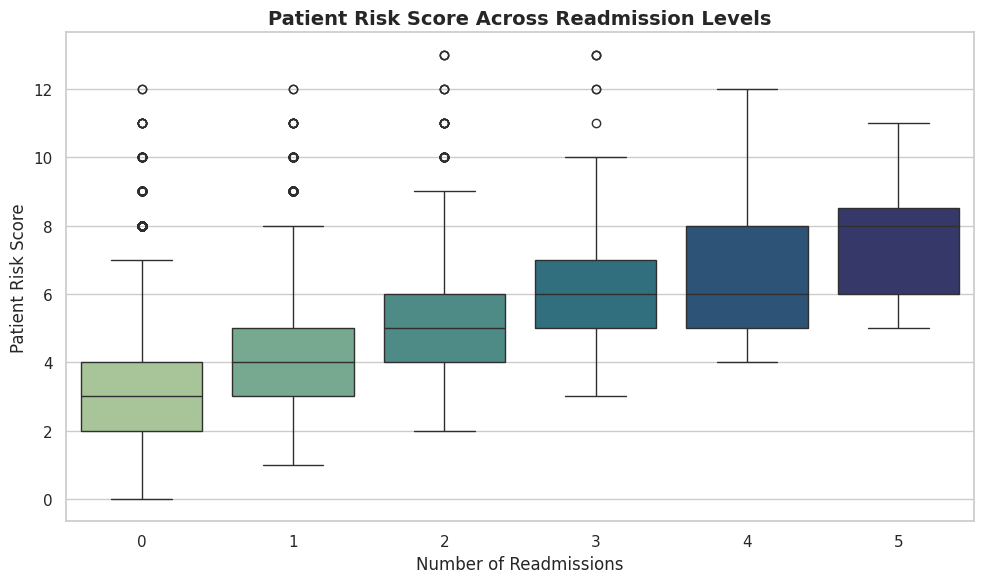

In [18]:
# 1. Create the Boxplot with crest palette
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='readmission_count',
    y='patient_risk_score',
    hue='readmission_count',
    palette='crest',
    legend=False
)

# 2. Add titles and labels
plt.title('Patient Risk Score Across Readmission Levels',
          fontsize=14, fontweight='bold')

plt.xlabel('Number of Readmissions', fontsize=12)
plt.ylabel('Patient Risk Score', fontsize=12)

# 3. Final layout adjustment
plt.tight_layout()
plt.show()

### 3.8 Distribution of Patient Risk Scores

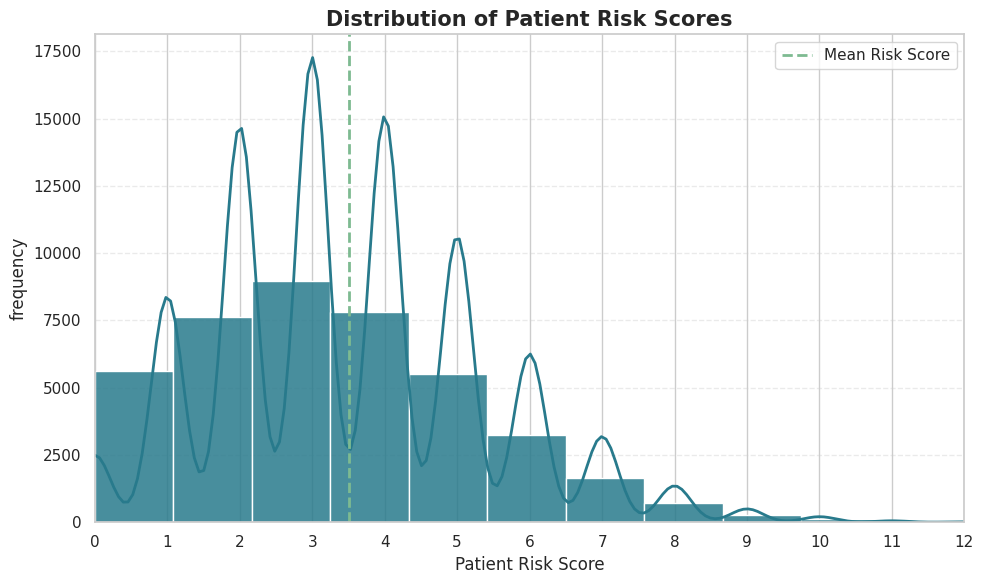

In [19]:
# 1. Create the histogram to visualize the distribution of patient risk scores
plt.figure(figsize=(10,6))

palette = sns.color_palette("crest")

sns.histplot(
    df['patient_risk_score'],
    bins=12,
    color=palette[3],
    edgecolor="white",
    alpha=0.85,
    kde=True,
    line_kws={"color": palette[0], "linewidth": 2}
)

# 2. Add mean line
plt.axvline(
    df['patient_risk_score'].mean(),
    color=palette[0],
    linestyle="--",
    linewidth=2,
    label="Mean Risk Score"
)

# 3. Titles and labels
plt.title("Distribution of Patient Risk Scores", fontsize=15, weight="bold")
plt.xlabel("Patient Risk Score", fontsize=12)
plt.ylabel("frequency", fontsize=12)

# 4. Improve axis readability
plt.xlim(0,10)
plt.xticks(range(0,13))

# 5. Grid
plt.grid(axis='y', linestyle='--', alpha=0.4)

# 6. Legend
plt.legend()

# 7. Final layout
plt.tight_layout()
plt.show()

### 3.9 Distribution of Average Length of Stay

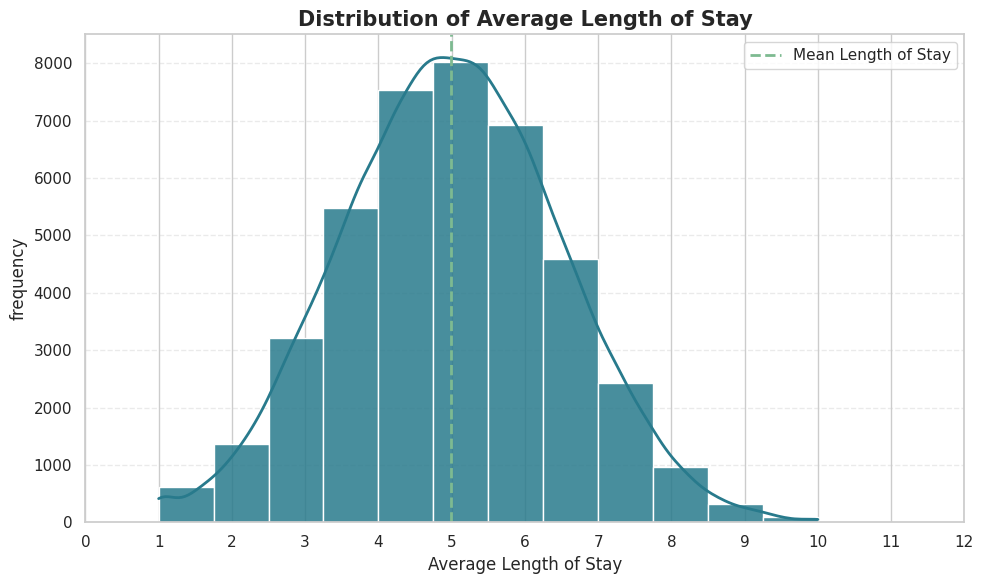

In [20]:
# 1. Create the histogram to visualize the distribution of average hospital length of stay

plt.figure(figsize=(10,6))

palette = sns.color_palette("crest")

sns.histplot(
    df['length_of_stay_avg'],
    bins=12,
    color=palette[3],
    edgecolor="white",
    alpha=0.85,
    kde=True,
    line_kws={"color": palette[0], "linewidth": 2}
)

# 2. Add mean line
plt.axvline(
    df['length_of_stay_avg'].mean(),
    color=palette[0],
    linestyle="--",
    linewidth=2,
    label="Mean Length of Stay"
)

# 3. Add titles and labels
plt.title("Distribution of Average Length of Stay", fontsize=15, weight="bold")
plt.xlabel("Average Length of Stay", fontsize=12)
plt.ylabel("frequency", fontsize=12)

# 4. Improve readability
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.xlim(0,10)
plt.xticks(range(0,13))
# 5. Show legend
plt.legend()

# 6. Final layout
plt.tight_layout()
plt.show()

### 3.10 Most Common Condition by City

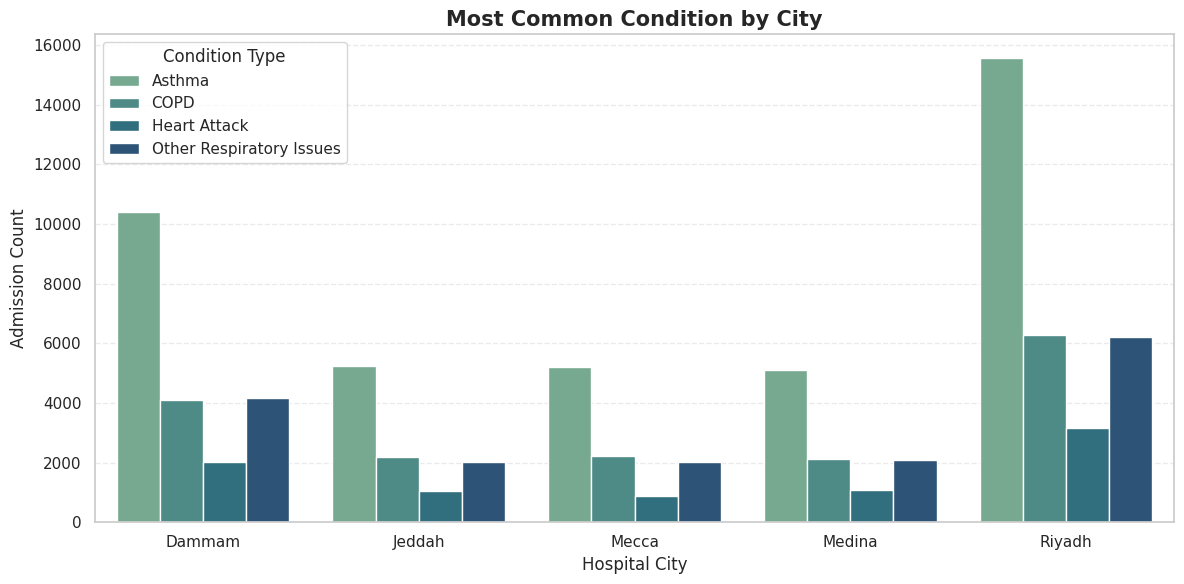

In [21]:
# 1. Aggregate admission counts by city and condition type
city_condition = df.groupby(['hospital_city', 'condition_type'])['admission_count'].sum().reset_index()

# 2. Create the grouped bar chart
plt.figure(figsize=(12,6))

sns.barplot(
    data=city_condition,
    x='hospital_city',
    y='admission_count',
    hue='condition_type',
    palette='crest'
)

# 3. Add titles and labels
plt.title('Most Common Condition by City', fontsize=15, weight='bold')
plt.xlabel('Hospital City', fontsize=12)
plt.ylabel('Admission Count', fontsize=12)

# 4. Improve readability
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.legend(title='Condition Type')

# 5. Final layout
plt.tight_layout()
plt.show()

### 3.11 Most Common Condition by Year

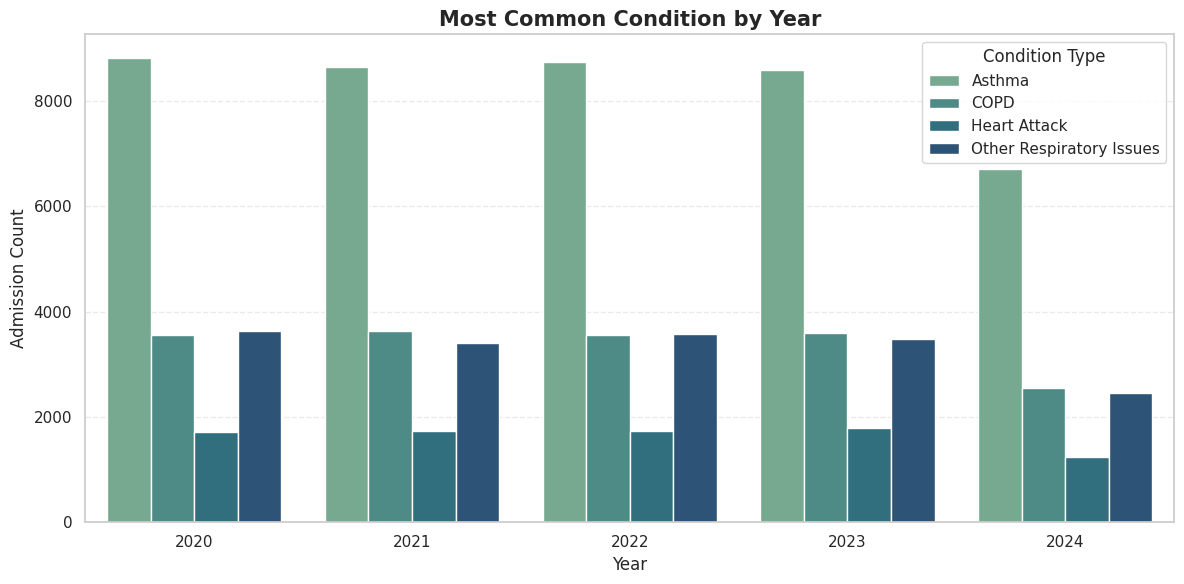

In [22]:
# 1. Convert admission_date to datetime
df['admission_date'] = pd.to_datetime(df['admission_date'])

# 2. Aggregate admission counts by year and condition
year_condition = df.groupby(['admission_year','condition_type'])['admission_count'].sum().reset_index()

# 3. Create the grouped bar chart
plt.figure(figsize=(12,6))

sns.barplot(
    data=year_condition,
    x='admission_year',
    y='admission_count',
    hue='condition_type',
    palette='crest'
)

# 4. Add titles and labels
plt.title('Most Common Condition by Year', fontsize=15, weight='bold')
plt.xlabel('Year')
plt.ylabel('Admission Count')

# 5. Improve readability
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.legend(title='Condition Type')

# 6. Final layout
plt.tight_layout()
plt.show()

# 4. Outliers Handling

### 4.1 Check Outliers

In [23]:
# Select numerical columns
numeric_cols = [
    'admission_count',
    'readmission_count',
    'length_of_stay_avg',
    'comorbid_conditions_count',
    'daily_medication_dosage',
    'emergency_visit_count',
    'admission_month',
    'patient_risk_score',
    'admission_year'
]

# Detect outliers using IQR
outlier_summary = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers_count = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col].count()

    outlier_summary.append({
        'Column': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Number of Outliers': outliers_count
    })

# Convert results to DataFrame
outlier_df = pd.DataFrame(outlier_summary)

# Display summary table
display(outlier_df)

,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Number of Outliers
0,admission_count,1.000000,3.000000,2.000000,-2.000000,6.000000,189
1,readmission_count,0.000000,1.000000,1.000000,-1.500000,2.500000,602
2,length_of_stay_avg,3.963454,6.008598,2.045144,0.895737,9.076314,145
3,comorbid_conditions_count,1.000000,3.000000,2.000000,-2.000000,6.000000,211
4,daily_medication_dosage,16.646086,23.409451,6.763365,6.501039,33.554498,249
5,emergency_visit_count,0.000000,2.000000,2.000000,-3.000000,5.000000,26
6,admission_month,3.000000,9.000000,6.000000,-6.000000,18.000000,0
7,patient_risk_score,2.000000,5.000000,3.000000,-2.500000,9.500000,151
8,admission_year,2021.000000,2023.000000,2.000000,2018.000000,2026.000000,0


### 4.2 Handling Outliers

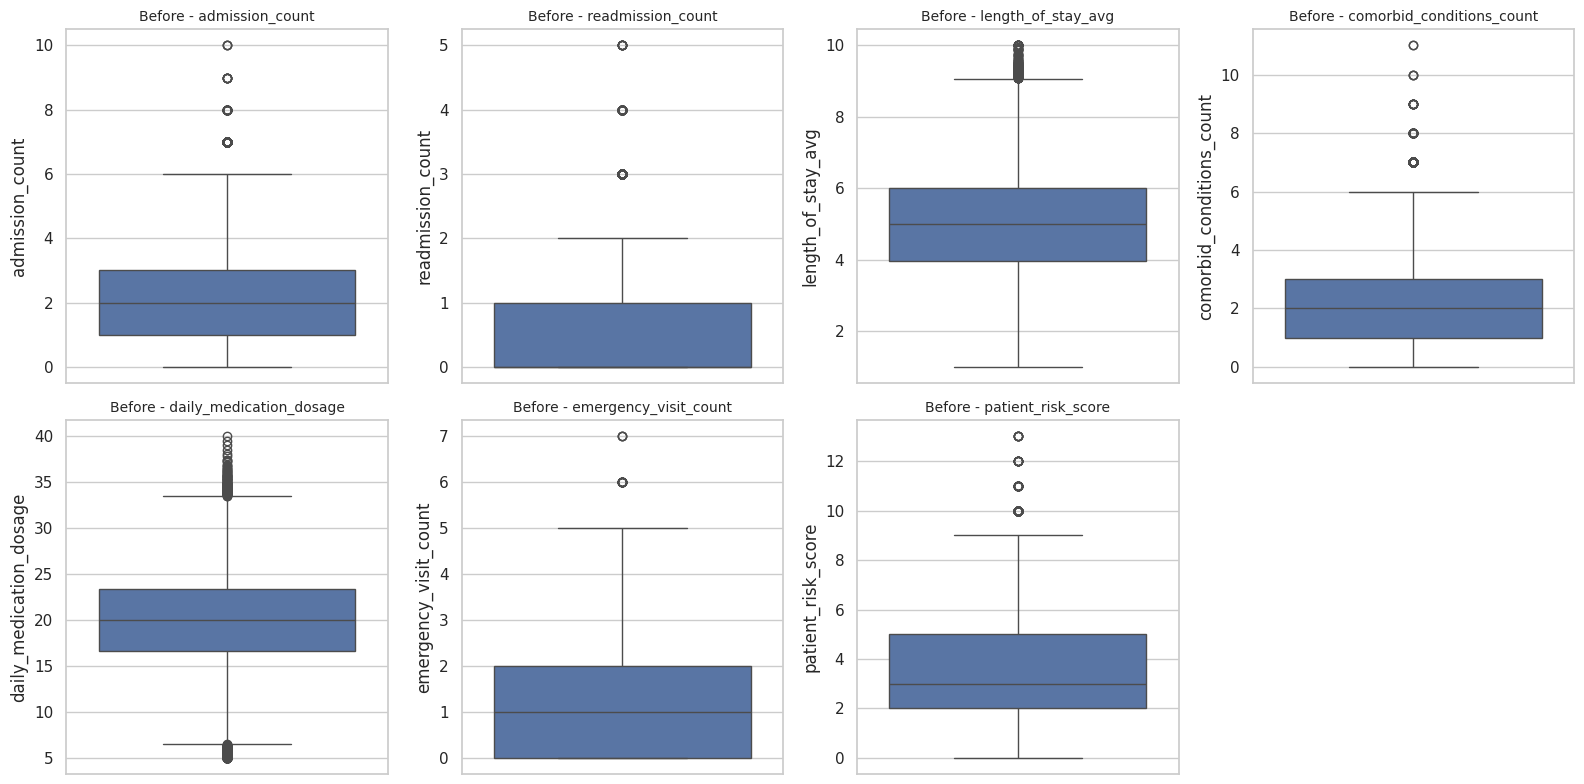

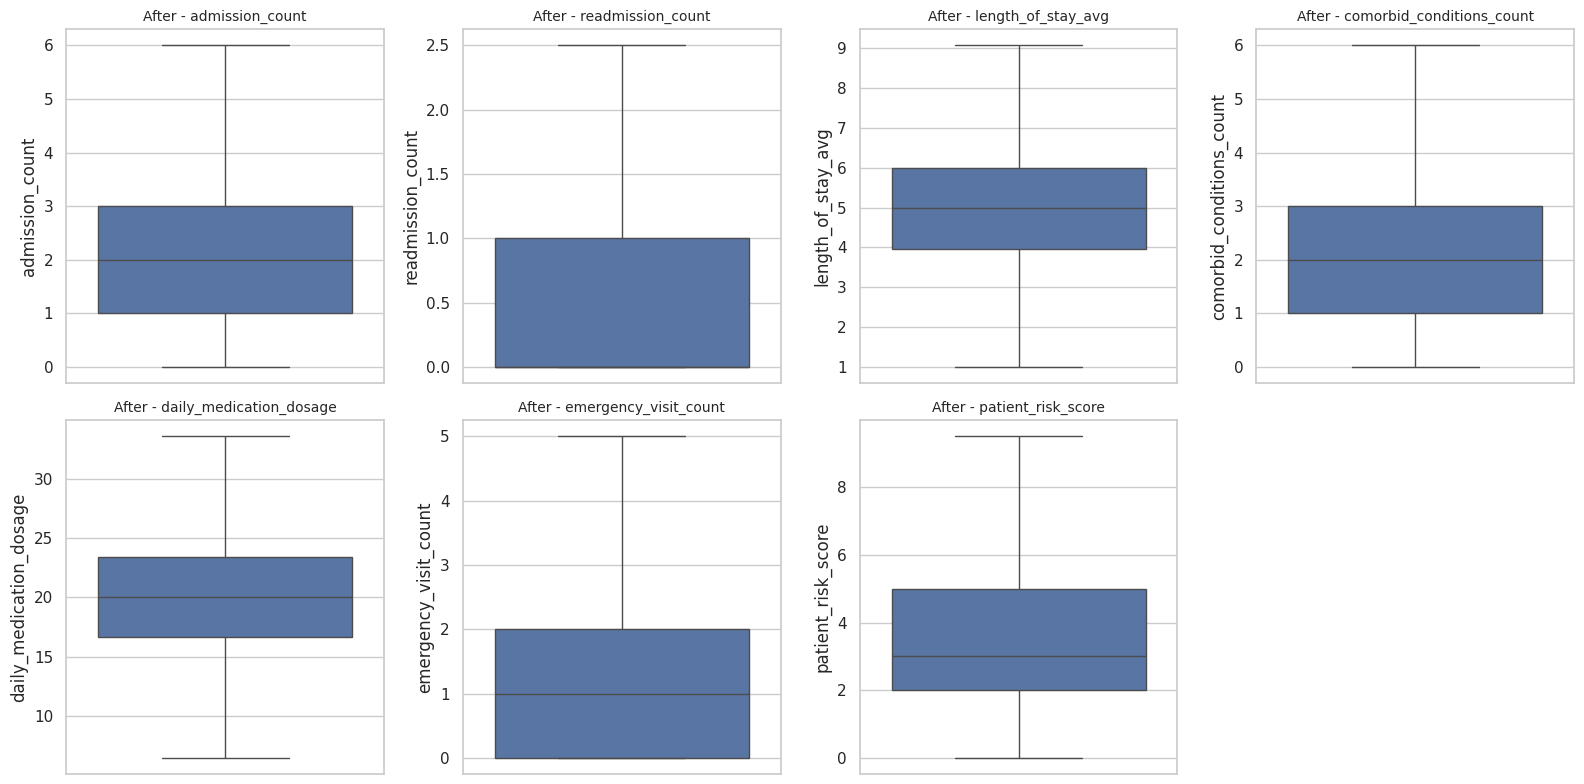

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns (only those with outliers)
numeric_cols = [
    'admission_count',
    'readmission_count',
    'length_of_stay_avg',
    'comorbid_conditions_count',
    'daily_medication_dosage',
    'emergency_visit_count',
    'patient_risk_score'
]

# Create a copy of the dataset
df_outliers_handled = df.copy()

# Apply IQR-based capping
for col in numeric_cols:
    Q1 = df_outliers_handled[col].quantile(0.25)
    Q3 = df_outliers_handled[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_outliers_handled[col] = df_outliers_handled[col].clip(lower=lower_bound, upper=upper_bound)

# =========================================
# Boxplots Before Handling
# =========================================
plt.figure(figsize=(16,8))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2,4,i)
    sns.boxplot(y=df[col])
    plt.title(f'Before - {col}', fontsize=10)

plt.tight_layout()
plt.show()

# =========================================
# Boxplots After Handling
# =========================================
plt.figure(figsize=(16,8))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2,4,i)
    sns.boxplot(y=df_outliers_handled[col])
    plt.title(f'After - {col}', fontsize=10)

plt.tight_layout()
plt.show()

# 5. Advanced State & 2nd Pre-processing

### 5.1 Dataset overview

In [25]:
# Import necessary libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Set professional visualization theme
sns.set_theme(style="whitegrid")

# Display the first 5 rows
print("----- Initial Overview (First 5 Rows) -----")
display(df.head())

# Check dataset structure and data types
print("\n----- Dataset Information -----")
df.info()

----- Initial Overview (First 5 Rows) -----


,admission_date,hospital_name,admission_count,condition_type,patient_age_group,patient_gender,readmission_count,severity_level,length_of_stay_avg,seasonal_indicator,comorbid_conditions_count,primary_diagnosis_code,daily_medication_dosage,emergency_visit_count,admission_month,admission_year,patient_risk_score,hospital_city
0,2020-01-01 00:00:00,Mecca City Hospital,1,Asthma,46-65,Female,0,Moderate,2.781828,Winter,1,Other,17.455517,2,1,2020,3,Mecca
1,2020-01-01 01:00:00,Dammam General Hospital,2,Asthma,0-17,Female,1,Mild,4.141432,Winter,0,Other,15.099498,3,1,2020,4,Dammam
2,2020-01-01 02:00:00,Mecca City Hospital,1,Asthma,46-65,Female,1,Moderate,8.507026,Winter,2,I21,23.087843,3,1,2020,6,Mecca
3,2020-01-01 03:00:00,Medina Specialist Hospital,3,Asthma,46-65,Male,0,Mild,4.622657,Winter,3,J45,25.247579,2,1,2020,5,Medina
4,2020-01-01 04:00:00,Medina Specialist Hospital,5,COPD,18-45,Female,2,Moderate,5.818385,Winter,3,J45,18.255290,1,1,2020,6,Medina



----- Dataset Information -----
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41544 entries, 0 to 41543
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   admission_date             41544 non-null  datetime64[ns]
 1   hospital_name              41544 non-null  object        
 2   admission_count            41544 non-null  int64         
 3   condition_type             41544 non-null  object        
 4   patient_age_group          41544 non-null  object        
 5   patient_gender             41544 non-null  object        
 6   readmission_count          41544 non-null  int64         
 7   severity_level             41544 non-null  object        
 8   length_of_stay_avg         41544 non-null  float64       
 9   seasonal_indicator         41544 non-null  object        
 10  comorbid_conditions_count  41544 non-null  int64         
 11  primary_diagnosis_code     41544 n

### 5.2 Visualized the Skewness Distribution

Skewness Values:
readmission_count            1.434615
emergency_visit_count        0.978995
comorbid_conditions_count    0.735973
admission_count              0.710526
patient_risk_score           0.531025
admission_month              0.069637
length_of_stay_avg           0.032570
daily_medication_dosage      0.000553
dtype: float64


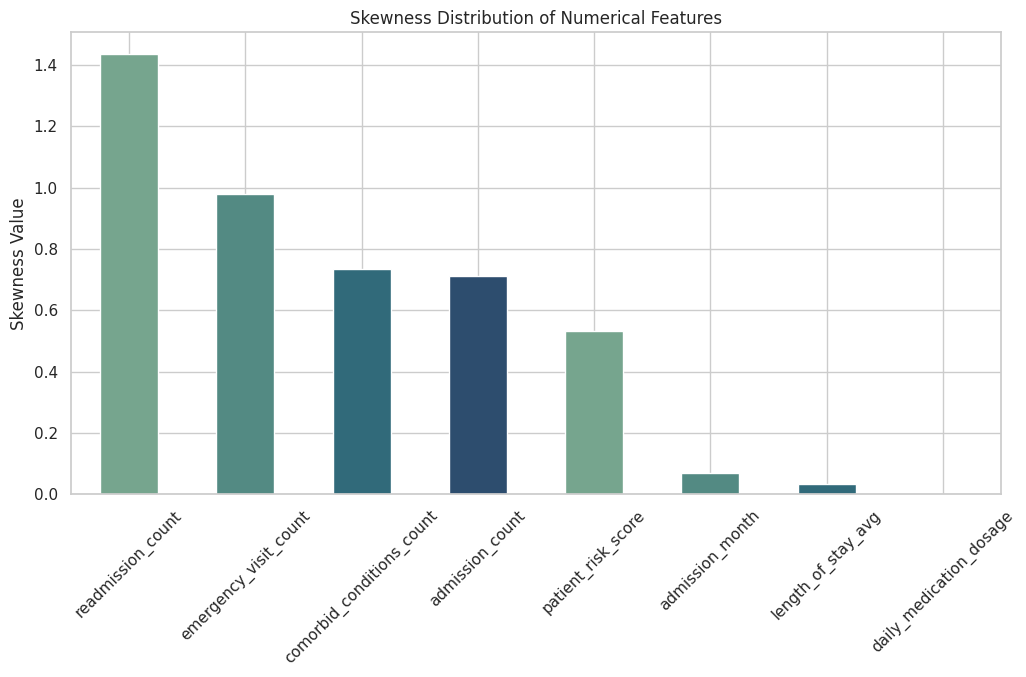

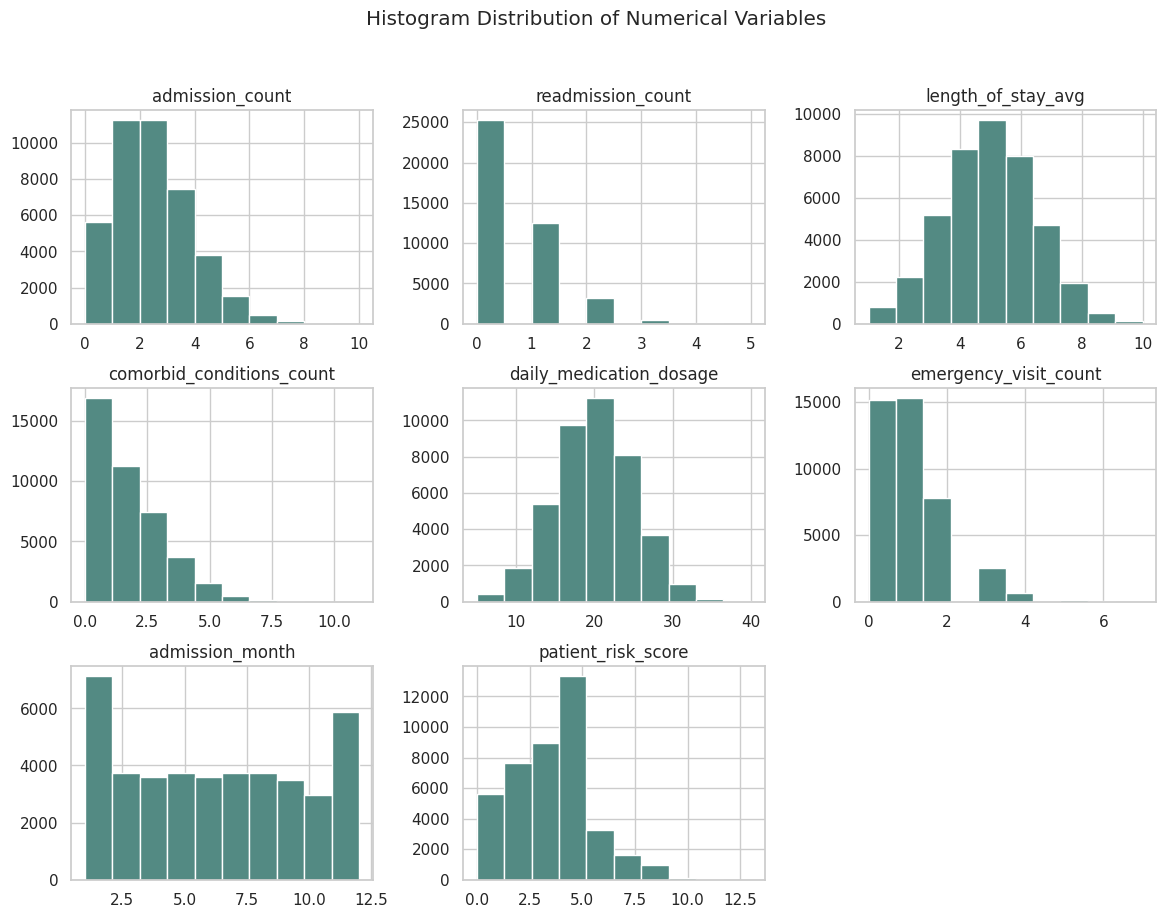

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# dataset
prepreocessed_df = df.copy()

# Select numerical columns
numeric_cols = prepreocessed_df.select_dtypes(include=['int64','float64']).columns

# Calculate skewness
skewness_values = prepreocessed_df[numeric_cols].skew().sort_values(ascending=False)

print("Skewness Values:")
print(skewness_values)

# Custom color palette
custom_colors = ['#76a58e', '#538a83', '#316a7a', '#2d4d6e']

# Plot skewness bar chart
plt.figure(figsize=(12,6))
skewness_values.plot(kind='bar', color=custom_colors)
plt.title("Skewness Distribution of Numerical Features")
plt.ylabel("Skewness Value")
plt.xticks(rotation=45)
plt.show()

# Plot histograms
prepreocessed_df[numeric_cols].hist(figsize=(14,10), color='#538a83')
plt.suptitle("Histogram Distribution of Numerical Variables")
plt.show()

### 5.3 Apply Log Transformation

Columns selected for log transformation:
['readmission_count', 'emergency_visit_count']

Skewness after log transformation:


,0
readmission_count,0.797893
emergency_visit_count,0.112928


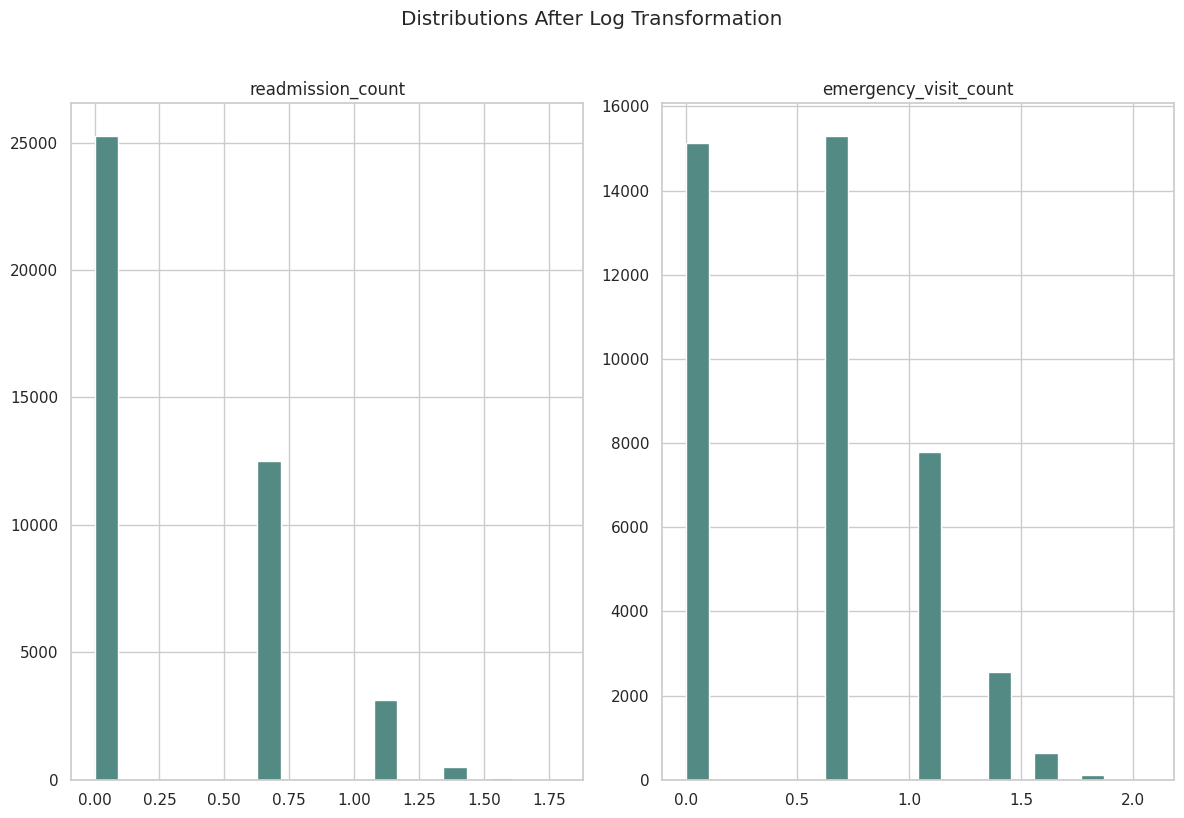

In [27]:
import numpy as np

# Create a copy after skewness inspection
df_log_transformed = prepreocessed_df.copy()

# Select positively skewed columns only
skewed_cols = skewness_values[skewness_values > 0.75].index.tolist()

# Exclude binary columns from log transformation
skewed_cols = [c for c in skewed_cols if df_log_transformed[c].nunique() > 2]

print("Columns selected for log transformation:")
print(skewed_cols)

# Apply log transformation
for col in skewed_cols:
    df_log_transformed[col] = np.log1p(df_log_transformed[col])

# Compare skewness after transformation
new_skewness = df_log_transformed[skewed_cols].skew().sort_values(ascending=False)

print("\nSkewness after log transformation:")
display(new_skewness)

# Plot transformed distributions
df_log_transformed[skewed_cols].hist(figsize=(12, 8), bins=20, color='#538a83')
plt.suptitle("Distributions After Log Transformation", y=1.02)
plt.tight_layout()
plt.show()

### 5.4 Apply Correlation

### 5.6 Encoding Categorical Variables

Correlation Matrix:


,admission_count,readmission_count,length_of_stay_avg,comorbid_conditions_count,daily_medication_dosage,emergency_visit_count,admission_month,patient_risk_score,admission_year
admission_count,1.000000,-0.003646,-0.004675,0.002552,0.004654,-0.009748,0.009257,-0.003792,-0.004566
readmission_count,-0.003646,1.000000,-0.001470,0.001024,0.002237,0.001451,0.000663,0.373425,0.003774
length_of_stay_avg,-0.004675,-0.001470,1.000000,-0.001507,-0.006281,0.002303,0.004545,-0.000885,-0.000460
comorbid_conditions_count,0.002552,0.001024,-0.001507,1.000000,-0.000303,0.000192,0.003775,0.757622,-0.005158
daily_medication_dosage,0.004654,0.002237,-0.006281,-0.000303,1.000000,-0.000297,-0.007916,0.000475,0.002256
emergency_visit_count,-0.009748,0.001451,0.002303,0.000192,-0.000297,1.000000,-0.001423,0.514956,-0.002942
admission_month,0.009257,0.000663,0.004545,0.003775,-0.007916,-0.001423,1.000000,0.002961,-0.111274
patient_risk_score,-0.003792,0.373425,-0.000885,0.757622,0.000475,0.514956,0.002961,1.000000,-0.004811
admission_year,-0.004566,0.003774,-0.000460,-0.005158,0.002256,-0.002942,-0.111274,-0.004811,1.000000


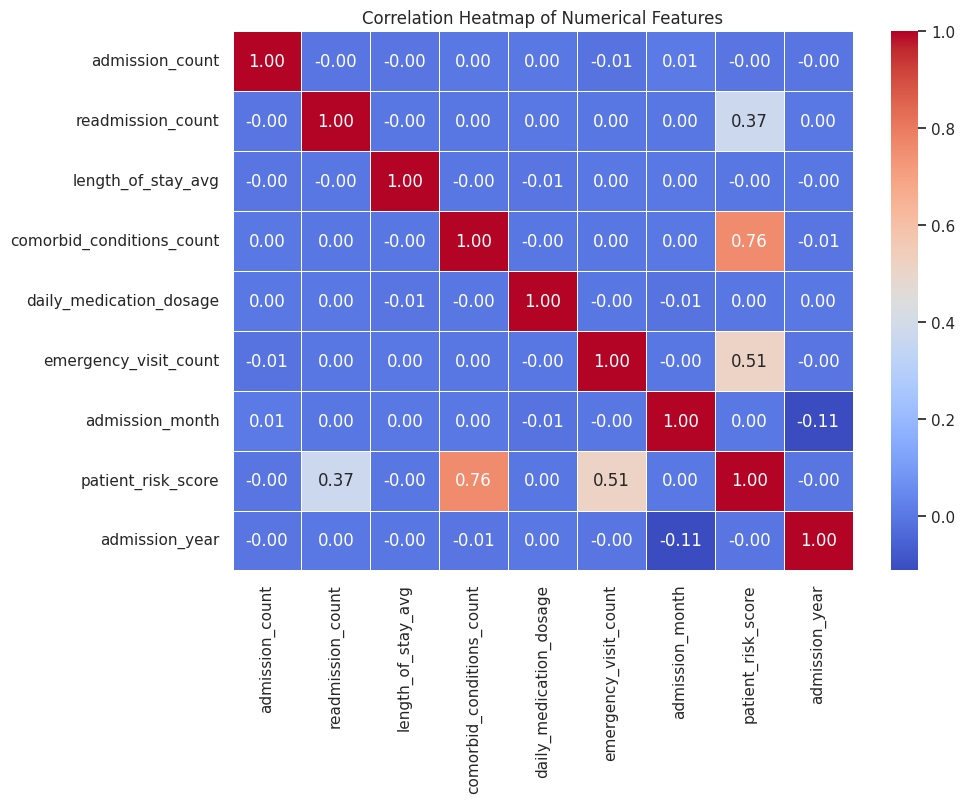

In [28]:
# Select only original numerical columns (excluding engineered features)
original_numeric_cols = [
    'admission_count', 'readmission_count', 'length_of_stay_avg',
    'comorbid_conditions_count', 'daily_medication_dosage',
    'emergency_visit_count', 'admission_month',
    'patient_risk_score', 'admission_year'
]

numeric_df = df_log_transformed[original_numeric_cols]

# Compute Pearson correlation matrix
correlation_matrix = numeric_df.corr(method='pearson')

# Display the correlation matrix
print("Correlation Matrix:")
display(correlation_matrix)

# Plot the heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

In [29]:
# Binary encoding for gender
df_log_transformed['patient_gender'] = df_log_transformed['patient_gender'].map({
    'Female': 0,
    'Male': 1
})

# Ordinal encoding for age group
age_map = {
    '0-17': 0,
    '18-45': 1,
    '46-65': 2,
    '66+': 3
}
df_log_transformed['patient_age_group'] = df_log_transformed['patient_age_group'].map(age_map)

# Ordinal encoding for severity level
severity_map = {
    'Mild': 0,
    'Moderate': 1,
    'Severe': 2
}
df_log_transformed['severity_level'] = df_log_transformed['severity_level'].map(severity_map)

# One-Hot Encoding for the remaining categorical columns
categorical_cols = [
    'condition_type',
    'seasonal_indicator',
    'hospital_city'
]

df_encoded = pd.get_dummies(df_log_transformed, columns=categorical_cols)

# Convert True/False columns to 0/1
bool_cols = df_encoded.select_dtypes(include='bool').columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

# Display settings
pd.set_option('display.max_columns', 10)
pd.set_option('display.width', 80)
pd.set_option('display.expand_frame_repr', True)

print(df_encoded.head())

       admission_date               hospital_name  admission_count  \
0 2020-01-01 00:00:00         Mecca City Hospital                1   
1 2020-01-01 01:00:00     Dammam General Hospital                2   
2 2020-01-01 02:00:00         Mecca City Hospital                1   
3 2020-01-01 03:00:00  Medina Specialist Hospital                3   
4 2020-01-01 04:00:00  Medina Specialist Hospital                5   

   patient_age_group  patient_gender  ...  hospital_city_Dammam  \
0                  2               0  ...                     0   
1                  0               0  ...                     1   
2                  2               0  ...                     0   
3                  2               1  ...                     0   
4                  1               0  ...                     0   

   hospital_city_Jeddah  hospital_city_Mecca  hospital_city_Medina  \
0                     0                    1                     0   
1                     0             

In [30]:
# =========================================
# Save Preprocessed Dataset
# =========================================

df_encoded.to_csv('Hospital_Dataset_preprocessed.csv', index=False)

print("Preprocessed dataset saved successfully.")
print("Dataset shape:", df_encoded.shape)

Preprocessed dataset saved successfully.
Dataset shape: (41544, 28)


# 6. Feature Selection Phase

6.1 Feature Selection Using XGBoost

Shape: (41544, 34)
Classes:
patient_risk_score
3     8949
4     7822
2     7630
5     5504
1     4346
6     3242
7     1650
0     1292
8      701
9      257
10     107
11      28
12      10
13       6
Name: count, dtype: int64

Top Features:
                       Feature  Importance
6    comorbid_conditions_count    0.080899
2               patient_gender    0.064408
22        hospital_city_Medina    0.055544
12         condition_type_COPD    0.052370
31  primary_diagnosis_code_J44    0.050474
8        emergency_visit_count    0.048428
3            readmission_count    0.047034
0              admission_count    0.040483
9              admission_month    0.039236
7      daily_medication_dosage    0.037524


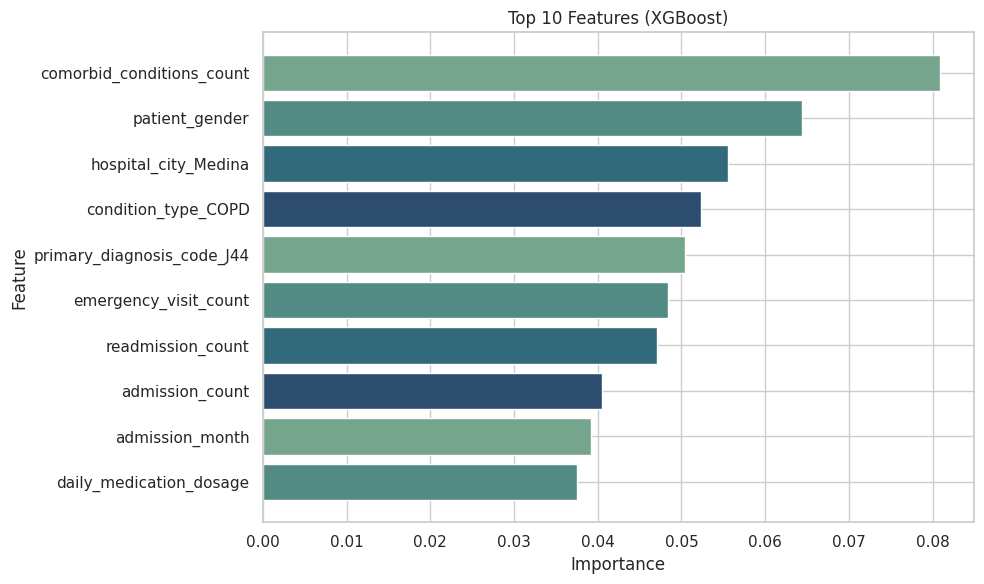

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight

# ── Data ─────────────────────────────────────────────────────────────────────
df_model = df_encoded.copy()

df_model['patient_risk_score'] = (
    df_model['patient_risk_score'].round().astype(int)
)

target_column = 'patient_risk_score'

df_model.replace([np.inf, -np.inf], np.nan, inplace=True)
df_model.dropna(subset=[target_column], inplace=True)
df_model.fillna(df_model.median(numeric_only=True), inplace=True)

if 'admission_date' in df_model.columns:
    df_model.drop(columns=['admission_date'], inplace=True)

df_model = pd.get_dummies(df_model, drop_first=True)

# ── X, y ─────────────────────────────────────────────────────────────────────
X = df_model.drop(columns=[target_column])
y = df_model[target_column]

print(f"Shape: {X.shape}")
print(f"Classes:\n{y.value_counts()}")

# ── Weights ──────────────────────────────────────────────────────────────────
sample_weights = compute_sample_weight(class_weight='balanced', y=y)

# ── Model ────────────────────────────────────────────────────────────────────
model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric='mlogloss'
)

model.fit(X, y, sample_weight=sample_weights)

# ── Feature Importance ───────────────────────────────────────────────────────
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nTop Features:")
print(importance_df.head(10))

# ── Custom Colors ────────────────────────────────────────────────────────────
custom_colors = ['#76a58e', '#538a83', '#316a7a', '#2d4d6e']
bar_colors = (custom_colors * 10)[:10]

# ── Plot ─────────────────────────────────────────────────────────────────────
plt.figure(figsize=(10, 6))
plt.barh(
    importance_df.head(10)['Feature'],
    importance_df.head(10)['Importance'],
    color=bar_colors,
    edgecolor='white'
)
plt.gca().invert_yaxis()
plt.title("Top 10 Features (XGBoost)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

#Assignment 2

### 6.2 Model 1 - leakage issue
###### 6.2.1 XGBoost Model


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, log_loss
)
from sklearn.utils.class_weight import compute_sample_weight

# ── Ranked feature list from cell 62 ──────────────────────────────────────
all_features_ranked = importance_df['Feature'].tolist()
total_features      = len(all_features_ranked)

# ── Number of classes from data (no hardcoding) ───────────────────────────
num_classes = y.nunique()
print(f'Number of classes : {num_classes}')
print(f'Classes           : {sorted(y.unique())}')

# ── Split BEFORE any model fitting to prevent leakage ─────────────────────
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
train_weights_full = compute_sample_weight(class_weight='balanced', y=y_train_full)

print(f'Training set size : {X_train_full.shape[0]}')
print(f'Test set size     : {X_test_full.shape[0]}')

# ── HYPERPARAMETER OPTIMIZATION (GridSearchCV + StratifiedKFold k=3) ──────
param_grid = {
    'n_estimators' : [100, 200],
    'learning_rate': [0.01, 0.02],
    'max_depth'    : [4, 6],
    'subsample'    : [0.6, 0.9],
    'gamma'        : [0, 0.1],
}

base_model = XGBClassifier(
    objective='multi:softprob',
    num_class=num_classes,
    eval_metric='mlogloss',
    random_state=42,
    verbosity=0
)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

print('\nRunning GridSearchCV on training data only — this will take several minutes...')
grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    cv=cv,
    scoring='roc_auc_ovr_weighted',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train_full, y_train_full, sample_weight=train_weights_full)

best_params = grid_search.best_params_
best_score  = grid_search.best_score_
print(f'\nBest hyperparameters : {best_params}')
print(f'Best CV AUC score    : {best_score:.4f}')

Number of classes : 14
Classes           : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13)]
Training set size : 33235
Test set size     : 8309

Running GridSearchCV on training data only — this will take several minutes...
Fitting 3 folds for each of 32 candidates, totalling 96 fits

Best hyperparameters : {'gamma': 0, 'learning_rate': 0.02, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.9}
Best CV AUC score    : 0.9994


###### 6.2.2 Model Evaluation


Evaluating model across feature subsets (on training data only)...
  Top   3 features -> AUC: 0.7194 +/- 0.0008 | Acc: 0.2327
  Top   5 features -> AUC: 0.7216 +/- 0.0013 | Acc: 0.2374
  Top  10 features -> AUC: 0.9995 +/- 0.0002 | Acc: 0.9849
  Top  15 features -> AUC: 0.9994 +/- 0.0002 | Acc: 0.9888
  Top  34 features -> AUC: 0.9994 +/- 0.0001 | Acc: 0.9880

Performance Comparison Across Feature Subsets:
 Number of Features  CV AUC (mean)  CV AUC (std)  CV Accuracy (mean)  Log Loss
                  3         0.7194        0.0008              0.2327    1.8489
                  5         0.7216        0.0013              0.2374    1.8414
                 10         0.9995        0.0002              0.9849    0.3341
                 15         0.9994        0.0002              0.9888    0.3322
                 34         0.9994        0.0001              0.9880    0.3380


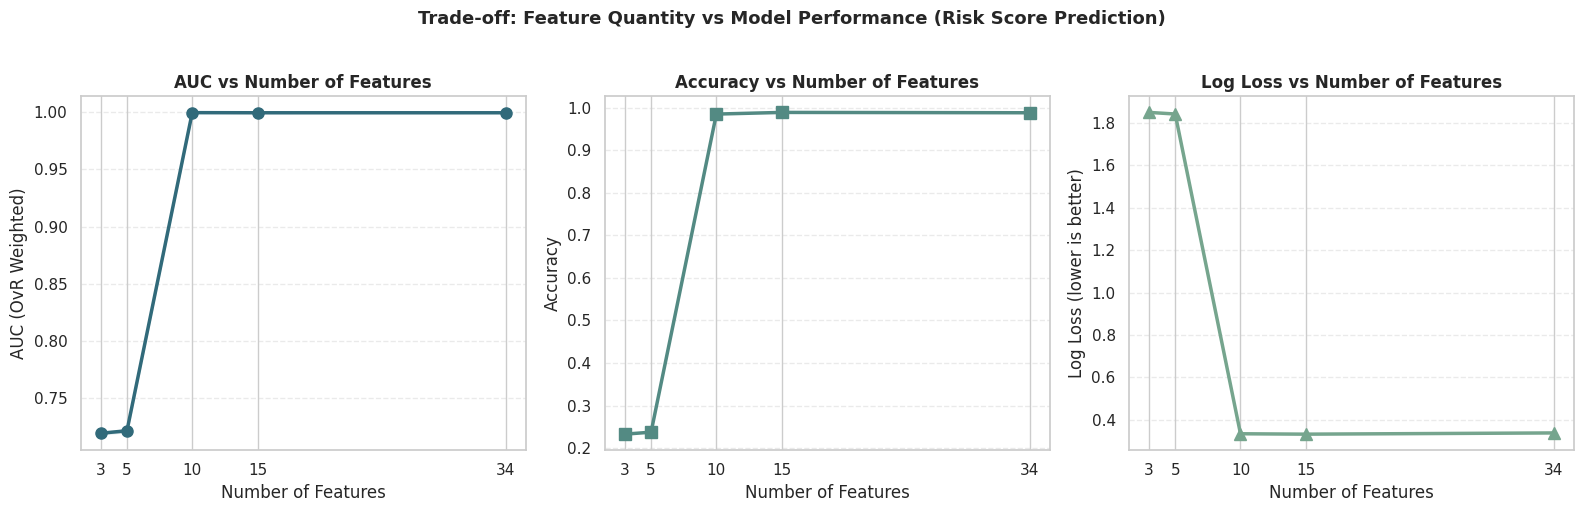


Best feature count : 10
Training set size  : 33235
Test set size      : 8309

Final Model — Classification Report (Test Set):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       258
           1       1.00      1.00      1.00       869
           2       1.00      1.00      1.00      1526
           3       1.00      1.00      1.00      1790
           4       1.00      1.00      1.00      1565
           5       1.00      0.99      1.00      1101
           6       0.99      1.00      0.99       649
           7       0.99      0.99      0.99       330
           8       0.92      0.99      0.95       140
           9       0.81      0.69      0.74        51
          10       0.48      0.57      0.52        21
          11       0.00      0.00      0.00         6
          12       1.00      0.50      0.67         2
          13       0.00      0.00      0.00         1

    accuracy                           0.99      8309
   macr

In [33]:
# PERFORMANCE ACROSS FEATURE SUBSETS (top 3, 5, 10, 15, all)
feature_subsets = [3, 5, 10, 15, total_features]
results         = []

print('\nEvaluating model across feature subsets (on training data only)...')

for n in feature_subsets:
    subset_features = all_features_ranked[:n]
    X_sub_train     = X_train_full[subset_features]
    X_sub_test      = X_test_full[subset_features]

    auc_folds = []
    acc_folds = []

    for train_idx, val_idx in cv.split(X_sub_train, y_train_full):
        X_tr, X_val = X_sub_train.iloc[train_idx], X_sub_train.iloc[val_idx]
        y_tr, y_val = y_train_full.iloc[train_idx], y_train_full.iloc[val_idx]
        w_tr        = train_weights_full[train_idx]

        fold_model = XGBClassifier(
            **best_params,
            objective='multi:softprob',
            num_class=num_classes,
            eval_metric='mlogloss',
            random_state=42,
            verbosity=0
        )
        fold_model.fit(X_tr, y_tr, sample_weight=w_tr)

        y_prob      = fold_model.predict_proba(X_val)
        y_pred_fold = fold_model.predict(X_val)

        auc_folds.append(
            roc_auc_score(y_val, y_prob, multi_class='ovr', average='weighted')
        )
        acc_folds.append((y_pred_fold == y_val.values).mean())

    auc_mean = np.mean(auc_folds)
    auc_std  = np.std(auc_folds)
    acc_mean = np.mean(acc_folds)

    subset_model = XGBClassifier(
        **best_params,
        objective='multi:softprob',
        num_class=num_classes,
        eval_metric='mlogloss',
        random_state=42,
        verbosity=0
    )
    w_sub_train = compute_sample_weight(class_weight='balanced', y=y_train_full)
    subset_model.fit(X_sub_train, y_train_full, sample_weight=w_sub_train)
    y_pred_prob_test = subset_model.predict_proba(X_sub_test)

    results.append({
        'Number of Features': n,
        'CV AUC (mean)'     : round(auc_mean, 4),
        'CV AUC (std)'      : round(auc_std,  4),
        'CV Accuracy (mean)': round(acc_mean, 4),
        'Log Loss'          : round(log_loss(y_test_full, y_pred_prob_test), 4),
    })
    print(f'  Top {n:>3} features -> AUC: {auc_mean:.4f} +/- '
          f'{auc_std:.4f} | Acc: {acc_mean:.4f}')

results_df = pd.DataFrame(results)
print('\nPerformance Comparison Across Feature Subsets:')
print(results_df.to_string(index=False))

# Plot AUC / Accuracy / Log Loss vs feature count
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
x_vals = results_df['Number of Features']

axes[0].plot(x_vals, results_df['CV AUC (mean)'], marker='o',
             color='#316a7a', linewidth=2.5, markersize=8)
axes[0].fill_between(
    x_vals,
    results_df['CV AUC (mean)'] - results_df['CV AUC (std)'],
    results_df['CV AUC (mean)'] + results_df['CV AUC (std)'],
    alpha=0.15, color='#316a7a'
)
axes[0].set_title('AUC vs Number of Features', fontweight='bold')
axes[0].set_xlabel('Number of Features')
axes[0].set_ylabel('AUC (OvR Weighted)')
axes[0].set_xticks(x_vals)
axes[0].grid(axis='y', linestyle='--', alpha=0.4)

axes[1].plot(x_vals, results_df['CV Accuracy (mean)'], marker='s',
             color='#538a83', linewidth=2.5, markersize=8)
axes[1].set_title('Accuracy vs Number of Features', fontweight='bold')
axes[1].set_xlabel('Number of Features')
axes[1].set_ylabel('Accuracy')
axes[1].set_xticks(x_vals)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

axes[2].plot(x_vals, results_df['Log Loss'], marker='^',
             color='#76a58e', linewidth=2.5, markersize=8)
axes[2].set_title('Log Loss vs Number of Features', fontweight='bold')
axes[2].set_xlabel('Number of Features')
axes[2].set_ylabel('Log Loss (lower is better)')
axes[2].set_xticks(x_vals)
axes[2].grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle('Trade-off: Feature Quantity vs Model Performance (Risk Score Prediction)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# FINAL MODEL
best_n          = results_df.loc[results_df['CV AUC (mean)'].idxmax(), 'Number of Features']
best_features   = all_features_ranked[:best_n]
X_best_train    = X_train_full[best_features]
X_best_test     = X_test_full[best_features]
final_weights   = compute_sample_weight(class_weight='balanced', y=y_train_full)

print(f'\nBest feature count : {best_n}')
print(f'Training set size  : {X_best_train.shape[0]}')
print(f'Test set size      : {X_best_test.shape[0]}')

final_model = XGBClassifier(
    **best_params,
    objective='multi:softprob',
    num_class=num_classes,
    eval_metric='mlogloss',
    random_state=42,
    verbosity=0
)
final_model.fit(X_best_train, y_train_full, sample_weight=final_weights)

y_pred      = final_model.predict(X_best_test)
y_pred_prob = final_model.predict_proba(X_best_test)

# Aliases for cells 68 and 69
X_best = X_best_test
y_test = y_test_full
print('\nFinal Model — Classification Report (Test Set):')
print(classification_report(y_test, y_pred, zero_division=0))

auc_final = roc_auc_score(y_test, y_pred_prob, multi_class='ovr', average='weighted')
print(f'AUC Score (OvR weighted) : {auc_final:.4f}')


###### 6.2.3 Visualized Results

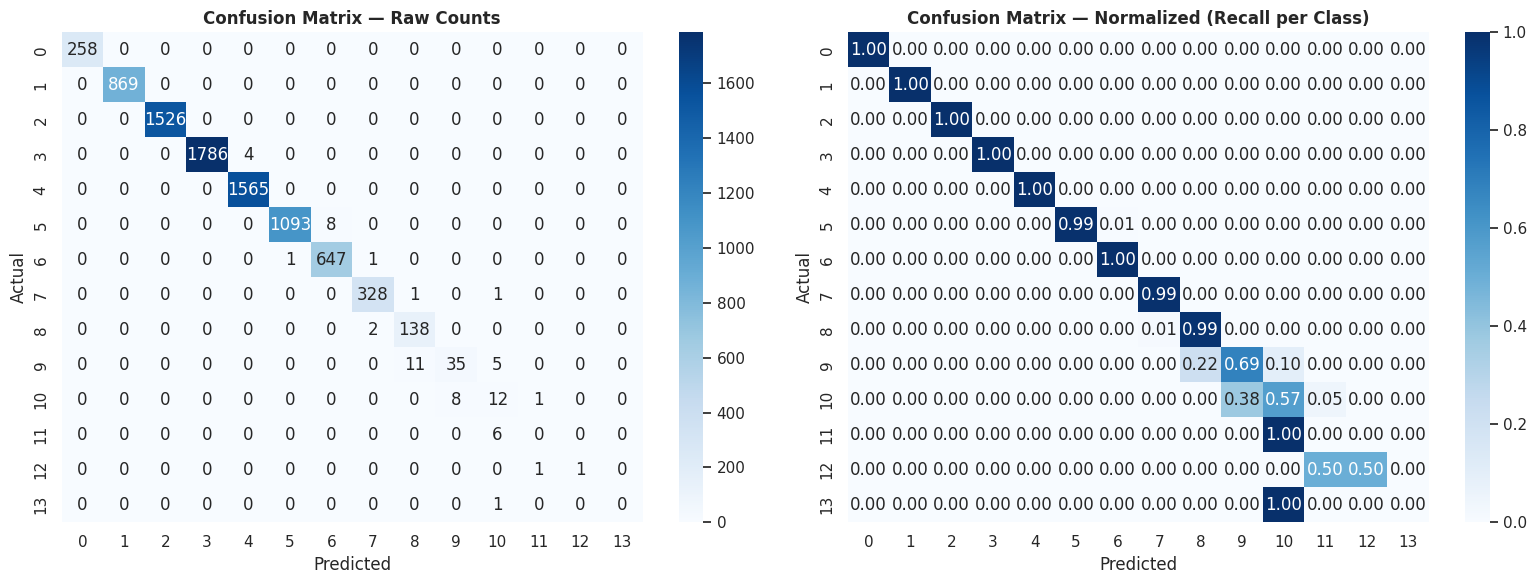


Top 10 Feature Importance (Final Model):
                   Feature  Importance
 comorbid_conditions_count    0.206316
       condition_type_COPD    0.127317
     emergency_visit_count    0.119141
         readmission_count    0.108927
   daily_medication_dosage    0.100745
           admission_month    0.079869
            patient_gender    0.077553
           admission_count    0.070329
primary_diagnosis_code_J44    0.070039
      hospital_city_Medina    0.039765


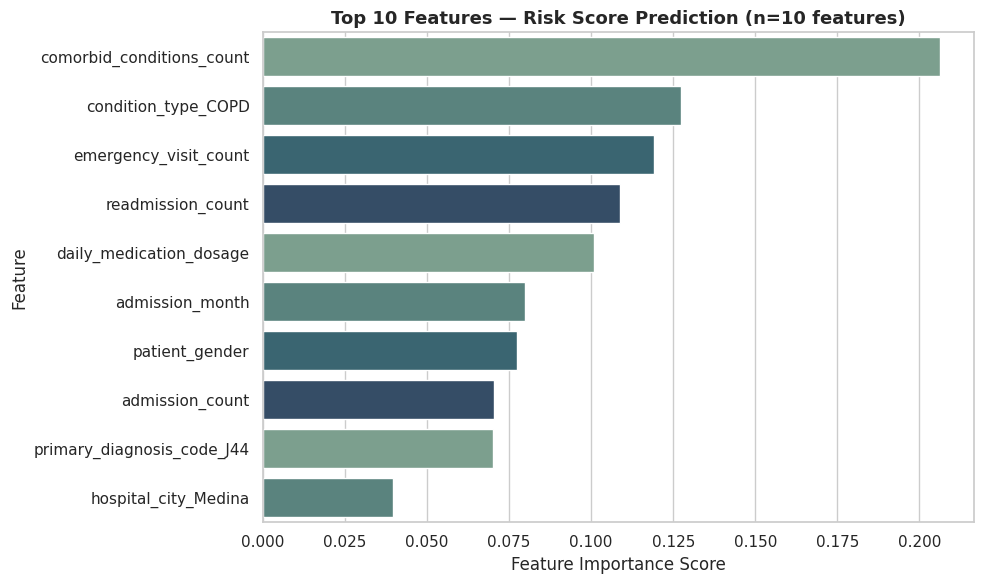

MODEL PERFORMANCE INTERPRETATION

Target variable  : patient_risk_score (14 classes)
Best features    : 10
Best parameters  : {'gamma': 0, 'learning_rate': 0.02, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.9}
Final AUC (OvR)  : 0.9999



In [34]:
# ── Custom colors ──────────────────────────────────────────────────────────
custom_colors = ['#76a58e', '#538a83', '#316a7a', '#2d4d6e']

cm      = confusion_matrix(y_test, y_pred)
cm_norm = confusion_matrix(y_test, y_pred, normalize='true')

tick_labels = [str(c) for c in sorted(y.unique())]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=tick_labels, yticklabels=tick_labels)
axes[0].set_title('Confusion Matrix — Raw Counts', fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=axes[1],
            xticklabels=tick_labels, yticklabels=tick_labels)
axes[1].set_title('Confusion Matrix — Normalized (Recall per Class)', fontweight='bold')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

# Feature importance
feature_importance_final = pd.DataFrame({
    'Feature'   : X_best.columns,
    'Importance': final_model.feature_importances_
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

print('\nTop 10 Feature Importance (Final Model):')
print(feature_importance_final.head(10).to_string(index=False))

n_bars       = min(10, len(feature_importance_final))
bar_colors_n = (custom_colors * 3)[:n_bars]

plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance_final.head(n_bars),
    x='Importance',
    y='Feature',
    hue='Feature',
    palette=bar_colors_n,
    legend=False
)
plt.title(f'Top {n_bars} Features — Risk Score Prediction (n={best_n} features)',
          fontsize=13, fontweight='bold')
plt.xlabel('Feature Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print('=' * 60)
print('MODEL PERFORMANCE INTERPRETATION')
print('=' * 60)
print(f"""
Target variable  : patient_risk_score ({num_classes} classes)
Best features    : {best_n}
Best parameters  : {best_params}
Final AUC (OvR)  : {auc_final:.4f}
""")

###### 6.2.4 Save

In [35]:
results_export = X_best.copy()
results_export['actual']    = y_test.values
results_export['predicted'] = y_pred
results_export['correct']   = (results_export['actual'] == results_export['predicted']).astype(int)

for i, cls in enumerate(sorted(y.unique())):
    results_export[f'prob_score_{cls}'] = y_pred_prob[:, i].round(4)

results_export.to_csv('medisight_model1_predictions.csv', index=False)
print(f'Saved {len(results_export)} rows to medisight_model1_predictions.csv')

# Download immediately to your device
from google.colab import files
files.download('medisight_model1_predictions.csv')

Saved 8309 rows to medisight_model1_predictions.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### 6.3 Model 2 - Fixed Leakage
###### 6.3.1 XGBoost Model

Dropping leaking columns: ['comorbid_conditions_count', 'emergency_visit_count', 'readmission_count']
Feature matrix shape : (41544, 31)
Number of classes    : 14

Training set size : 33235
Test set size     : 8309

Top Features:
                                  Feature  Importance
8                   condition_type_Asthma    0.067704
2                          patient_gender    0.066714
12                seasonal_indicator_Fall    0.057936
26  hospital_name_Riyadh General Hospital    0.052383
1                       patient_age_group    0.049098
5                 daily_medication_dosage    0.046616
7                          admission_year    0.042972
6                         admission_month    0.042249
21  hospital_name_Dammam General Hospital    0.041057
0                         admission_count    0.039825


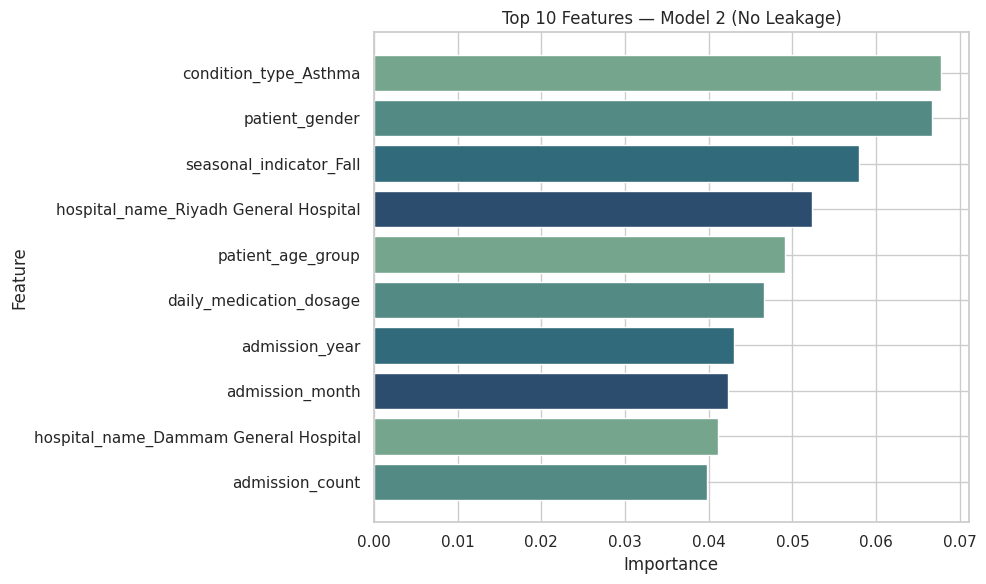


Running GridSearchCV on training set only...
Fitting 3 folds for each of 32 candidates, totalling 96 fits

Best hyperparameters : {'gamma': 0, 'learning_rate': 0.02, 'max_depth': 4, 'n_estimators': 100, 'subsample': 0.6}
Best CV AUC score    : 0.5002


In [36]:
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold

# ════════════════════════════════════════════════════════════════════════════
# STEP 1 — BUILD CLEAN X (drop leaking columns)
# ════════════════════════════════════════════════════════════════════════════

df_model_2 = df_encoded.copy()

df_model_2['patient_risk_score'] = (
    df_model_2['patient_risk_score'].round().astype(int)
)

df_model_2.replace([np.inf, -np.inf], np.nan, inplace=True)
df_model_2.dropna(subset=['patient_risk_score'], inplace=True)
df_model_2.fillna(df_model_2.median(numeric_only=True), inplace=True)

if 'admission_date' in df_model_2.columns:
    df_model_2.drop(columns=['admission_date'], inplace=True)

df_model_2 = pd.get_dummies(df_model_2, drop_first=True)

# Drop columns used to construct patient_risk_score
leaking_cols = ['comorbid_conditions_count', 'emergency_visit_count', 'readmission_count']
leaking_cols = [c for c in leaking_cols if c in df_model_2.columns]
print(f'Dropping leaking columns: {leaking_cols}')
df_model_2.drop(columns=leaking_cols, inplace=True)

X_2 = df_model_2.drop(columns=['patient_risk_score'])
y_2 = df_model_2['patient_risk_score']

num_classes_2 = y_2.nunique()
print(f'Feature matrix shape : {X_2.shape}')
print(f'Number of classes    : {num_classes_2}')

# ════════════════════════════════════════════════════════════════════════════
# STEP 2 — TRAIN / TEST SPLIT
# ════════════════════════════════════════════════════════════════════════════

X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(
    X_2, y_2,
    test_size=0.2,
    random_state=42,
    stratify=y_2
)

train_weights_2 = compute_sample_weight(class_weight='balanced', y=y_train_2)

print(f'\nTraining set size : {X_train_2.shape[0]}')
print(f'Test set size     : {X_test_2.shape[0]}')

# ════════════════════════════════════════════════════════════════════════════
# STEP 3 — FEATURE IMPORTANCE (on full clean data)
# ════════════════════════════════════════════════════════════════════════════

sample_weights_2 = compute_sample_weight(class_weight='balanced', y=y_2)

importance_model_2 = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric='mlogloss',
    verbosity=0
)
importance_model_2.fit(X_2, y_2, sample_weight=sample_weights_2)

importance_df_2 = pd.DataFrame({
    'Feature'   : X_2.columns,
    'Importance': importance_model_2.feature_importances_
}).sort_values(by='Importance', ascending=False)

all_features_ranked_2 = importance_df_2['Feature'].tolist()
total_features_2      = len(all_features_ranked_2)

print('\nTop Features:')
print(importance_df_2.head(10))

custom_colors = ['#76a58e', '#538a83', '#316a7a', '#2d4d6e']
bar_colors    = (custom_colors * 10)[:10]

plt.figure(figsize=(10, 6))
plt.barh(
    importance_df_2.head(10)['Feature'],
    importance_df_2.head(10)['Importance'],
    color=bar_colors,
    edgecolor='white'
)
plt.gca().invert_yaxis()
plt.title('Top 10 Features — Model 2 (No Leakage)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# ════════════════════════════════════════════════════════════════════════════
# STEP 4 — HYPERPARAMETER OPTIMIZATION (on training set only)
# ════════════════════════════════════════════════════════════════════════════

param_grid_2 = {
    'n_estimators' : [100, 200],
    'learning_rate': [0.01, 0.02],
    'max_depth'    : [4, 6],
    'subsample'    : [0.6, 0.9],
    'gamma'        : [0, 0.1],
}

base_model_2 = XGBClassifier(
    objective='multi:softprob',
    num_class=num_classes_2,
    eval_metric='mlogloss',
    random_state=42,
    verbosity=0
)

cv_2 = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

print('\nRunning GridSearchCV on training set only...')
grid_search_2 = GridSearchCV(
    estimator=base_model_2,
    param_grid=param_grid_2,
    cv=cv_2,
    scoring='roc_auc_ovr_weighted',
    n_jobs=-1,
    verbose=1
)

grid_search_2.fit(X_train_2, y_train_2, sample_weight=train_weights_2)

best_params_2 = grid_search_2.best_params_
best_score_2  = grid_search_2.best_score_

print(f'\nBest hyperparameters : {best_params_2}')
print(f'Best CV AUC score    : {best_score_2:.4f}')


Evaluating model across feature subsets (on training data only)...
  Top   3 features -> AUC: 0.5016 +/- 0.0012 | Acc: 0.0241
  Top   5 features -> AUC: 0.5032 +/- 0.0012 | Acc: 0.0218
  Top  10 features -> AUC: 0.5009 +/- 0.0008 | Acc: 0.0521
  Top  15 features -> AUC: 0.5014 +/- 0.0005 | Acc: 0.0552
  Top  31 features -> AUC: 0.5002 +/- 0.0016 | Acc: 0.0607

Performance Comparison Across Feature Subsets:
 Number of Features  CV AUC (mean)  CV AUC (std)  CV Accuracy (mean)  Log Loss
                  3         0.5016        0.0012              0.0241    2.6314
                  5         0.5032        0.0012              0.0218    2.6043
                 10         0.5009        0.0008              0.0521    2.5189
                 15         0.5014        0.0005              0.0552    2.5147
                 31         0.5002        0.0016              0.0607    2.5037


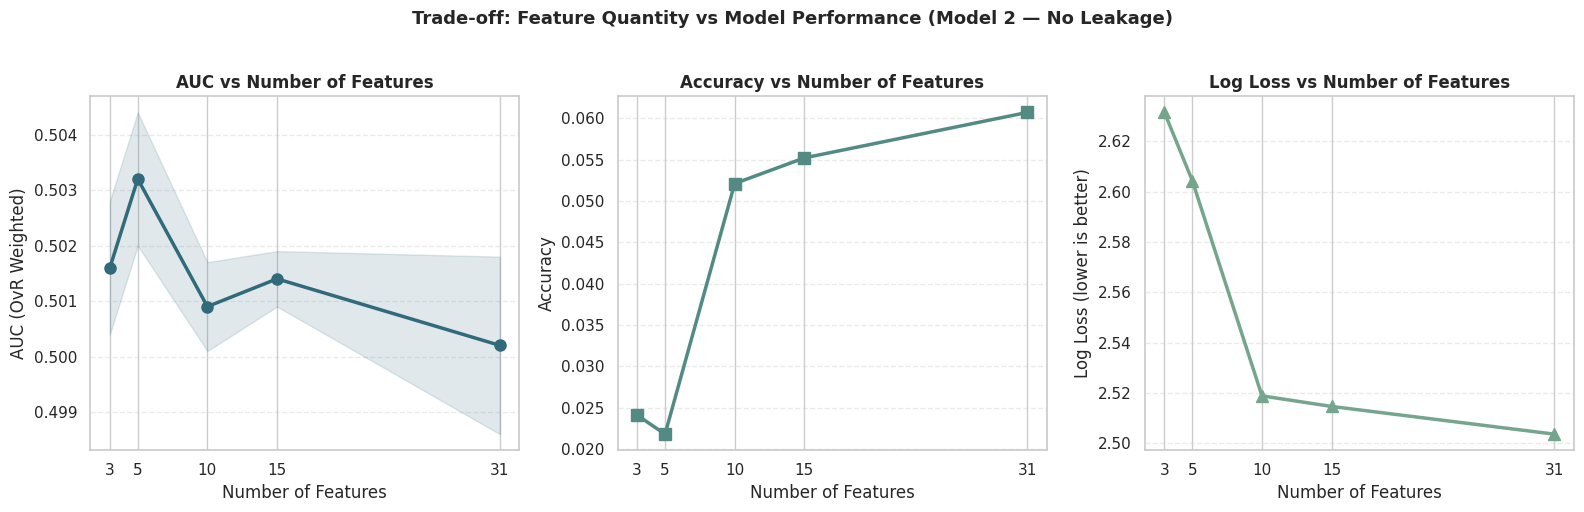


Best feature count : 5
Training set size  : 33235
Test set size      : 8309

Final Model 2 — Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.03      0.05      0.03       258
           1       0.09      0.05      0.06       869
           2       0.14      0.00      0.01      1526
           3       0.00      0.00      0.00      1790
           4       0.20      0.07      0.10      1565
           5       0.12      0.01      0.01      1101
           6       0.00      0.00      0.00       649
           7       0.11      0.02      0.03       330
           8       0.01      0.02      0.01       140
           9       0.01      0.12      0.01        51
          10       0.00      0.19      0.01        21
          11       0.00      0.33      0.00         6
          12       0.00      0.00      0.00         2
          13       0.00      1.00      0.00         1

    accuracy                           0.02      8309
   mac

In [37]:
import warnings
from sklearn.exceptions import UndefinedMetricWarning

# PERFORMANCE ACROSS FEATURE SUBSETS (top 3, 5, 10, 15, all)
feature_subsets_2 = [3, 5, 10, 15, total_features_2]
results_2         = []

print('\nEvaluating model across feature subsets (on training data only)...')

for n in feature_subsets_2:
    subset_features = all_features_ranked_2[:n]
    X_sub_train     = X_train_2[subset_features]
    X_sub_test      = X_test_2[subset_features]

    auc_folds = []
    acc_folds = []

    for train_idx, val_idx in cv_2.split(X_sub_train, y_train_2):
        X_tr, X_val = X_sub_train.iloc[train_idx], X_sub_train.iloc[val_idx]
        y_tr, y_val = y_train_2.iloc[train_idx],   y_train_2.iloc[val_idx]
        w_tr        = train_weights_2[train_idx]

        fold_model = XGBClassifier(
            **best_params_2,
            objective='multi:softprob',
            num_class=num_classes_2,
            eval_metric='mlogloss',
            random_state=42,
            verbosity=0
        )
        fold_model.fit(X_tr, y_tr, sample_weight=w_tr)

        y_prob      = fold_model.predict_proba(X_val)
        y_pred_fold = fold_model.predict(X_val)

        with warnings.catch_warnings():
            warnings.simplefilter('ignore', UndefinedMetricWarning)
            auc_folds.append(
                roc_auc_score(y_val, y_prob, multi_class='ovr', average='weighted',
                              labels=sorted(y_train_2.unique()))
            )
        acc_folds.append((y_pred_fold == y_val.values).mean())

    auc_mean = np.mean(auc_folds)
    auc_std  = np.std(auc_folds)
    acc_mean = np.mean(acc_folds)

    subset_model = XGBClassifier(
        **best_params_2,
        objective='multi:softprob',
        num_class=num_classes_2,
        eval_metric='mlogloss',
        random_state=42,
        verbosity=0
    )
    w_sub_train = compute_sample_weight(class_weight='balanced', y=y_train_2)
    subset_model.fit(X_sub_train, y_train_2, sample_weight=w_sub_train)
    y_pred_prob_test = subset_model.predict_proba(X_sub_test)

    with warnings.catch_warnings():
        warnings.simplefilter('ignore', UndefinedMetricWarning)
        results_2.append({
            'Number of Features': n,
            'CV AUC (mean)'     : round(auc_mean, 4),
            'CV AUC (std)'      : round(auc_std,  4),
            'CV Accuracy (mean)': round(acc_mean, 4),
            'Log Loss'          : round(log_loss(y_test_2, y_pred_prob_test), 4),
        })
    print(f'  Top {n:>3} features -> AUC: {auc_mean:.4f} +/- '
          f'{auc_std:.4f} | Acc: {acc_mean:.4f}')

results_df_2 = pd.DataFrame(results_2)
print('\nPerformance Comparison Across Feature Subsets:')
print(results_df_2.to_string(index=False))

# Plot AUC / Accuracy / Log Loss vs feature count
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
x_vals = results_df_2['Number of Features']

axes[0].plot(x_vals, results_df_2['CV AUC (mean)'], marker='o',
             color='#316a7a', linewidth=2.5, markersize=8)
axes[0].fill_between(
    x_vals,
    results_df_2['CV AUC (mean)'] - results_df_2['CV AUC (std)'],
    results_df_2['CV AUC (mean)'] + results_df_2['CV AUC (std)'],
    alpha=0.15, color='#316a7a'
)
axes[0].set_title('AUC vs Number of Features', fontweight='bold')
axes[0].set_xlabel('Number of Features')
axes[0].set_ylabel('AUC (OvR Weighted)')
axes[0].set_xticks(x_vals)
axes[0].grid(axis='y', linestyle='--', alpha=0.4)

axes[1].plot(x_vals, results_df_2['CV Accuracy (mean)'], marker='s',
             color='#538a83', linewidth=2.5, markersize=8)
axes[1].set_title('Accuracy vs Number of Features', fontweight='bold')
axes[1].set_xlabel('Number of Features')
axes[1].set_ylabel('Accuracy')
axes[1].set_xticks(x_vals)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

axes[2].plot(x_vals, results_df_2['Log Loss'], marker='^',
             color='#76a58e', linewidth=2.5, markersize=8)
axes[2].set_title('Log Loss vs Number of Features', fontweight='bold')
axes[2].set_xlabel('Number of Features')
axes[2].set_ylabel('Log Loss (lower is better)')
axes[2].set_xticks(x_vals)
axes[2].grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle('Trade-off: Feature Quantity vs Model Performance (Model 2 — No Leakage)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# FINAL MODEL
best_n_2        = results_df_2.loc[results_df_2['CV AUC (mean)'].idxmax(), 'Number of Features']
best_features_2 = all_features_ranked_2[:best_n_2]
X_best_train_2  = X_train_2[best_features_2]
X_best_test_2   = X_test_2[best_features_2]
final_weights_2 = compute_sample_weight(class_weight='balanced', y=y_train_2)

print(f'\nBest feature count : {best_n_2}')
print(f'Training set size  : {X_best_train_2.shape[0]}')
print(f'Test set size      : {X_best_test_2.shape[0]}')

final_model_2 = XGBClassifier(
    **best_params_2,
    objective='multi:softprob',
    num_class=num_classes_2,
    eval_metric='mlogloss',
    random_state=42,
    verbosity=0
)
final_model_2.fit(X_best_train_2, y_train_2, sample_weight=final_weights_2)

y_pred_2      = final_model_2.predict(X_best_test_2)
y_pred_prob_2 = final_model_2.predict_proba(X_best_test_2)

print('\nFinal Model 2 — Classification Report (Test Set):')
print(classification_report(y_test_2, y_pred_2, zero_division=0))

with warnings.catch_warnings():
    warnings.simplefilter('ignore', UndefinedMetricWarning)
    auc_final_2 = roc_auc_score(y_test_2, y_pred_prob_2, multi_class='ovr',
                                average='weighted', labels=sorted(y_2.unique()))

logloss_final_2 = log_loss(y_test_2, y_pred_prob_2)
print(f'AUC Score (OvR weighted) : {auc_final_2:.4f}')
print(f'Log Loss                 : {logloss_final_2:.4f}')

###### 6.3.2 Model Evaluation


Evaluating model across feature subsets (on training data only)...
  Top   3 features -> AUC: 0.5016 +/- 0.0012 | Acc: 0.0241
  Top   5 features -> AUC: 0.5032 +/- 0.0012 | Acc: 0.0218
  Top  10 features -> AUC: 0.5009 +/- 0.0008 | Acc: 0.0521
  Top  15 features -> AUC: 0.5014 +/- 0.0005 | Acc: 0.0552
  Top  31 features -> AUC: 0.5002 +/- 0.0016 | Acc: 0.0607

Performance Comparison Across Feature Subsets:
 Number of Features  CV AUC (mean)  CV AUC (std)  CV Accuracy (mean)  Log Loss
                  3         0.5016        0.0012              0.0241    2.6314
                  5         0.5032        0.0012              0.0218    2.6043
                 10         0.5009        0.0008              0.0521    2.5189
                 15         0.5014        0.0005              0.0552    2.5147
                 31         0.5002        0.0016              0.0607    2.5037


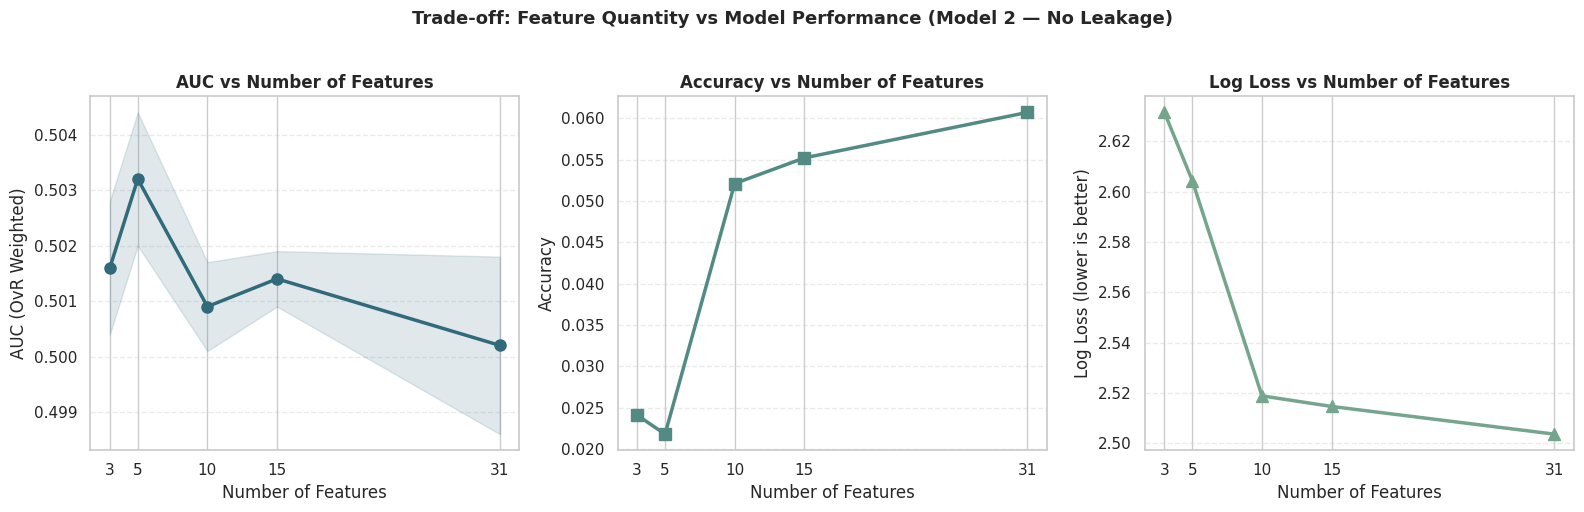


Best feature count : 5
Training set size  : 33235
Test set size      : 8309

Final Model 2 — Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.03      0.05      0.03       258
           1       0.09      0.05      0.06       869
           2       0.14      0.00      0.01      1526
           3       0.00      0.00      0.00      1790
           4       0.20      0.07      0.10      1565
           5       0.12      0.01      0.01      1101
           6       0.00      0.00      0.00       649
           7       0.11      0.02      0.03       330
           8       0.01      0.02      0.01       140
           9       0.01      0.12      0.01        51
          10       0.00      0.19      0.01        21
          11       0.00      0.33      0.00         6
          12       0.00      0.00      0.00         2
          13       0.00      1.00      0.00         1

    accuracy                           0.02      8309
   mac

In [39]:
import warnings
from sklearn.exceptions import UndefinedMetricWarning

# PERFORMANCE ACROSS FEATURE SUBSETS (top 3, 5, 10, 15, all)
feature_subsets_2 = [3, 5, 10, 15, total_features_2]
results_2         = []

print('\nEvaluating model across feature subsets (on training data only)...')

for n in feature_subsets_2:
    subset_features = all_features_ranked_2[:n]
    X_sub_train     = X_train_2[subset_features]
    X_sub_test      = X_test_2[subset_features]

    auc_folds = []
    acc_folds = []

    for train_idx, val_idx in cv_2.split(X_sub_train, y_train_2):
        X_tr, X_val = X_sub_train.iloc[train_idx], X_sub_train.iloc[val_idx]
        y_tr, y_val = y_train_2.iloc[train_idx],   y_train_2.iloc[val_idx]
        w_tr        = train_weights_2[train_idx]

        fold_model = XGBClassifier(
            **best_params_2,
            objective='multi:softprob',
            num_class=num_classes_2,
            eval_metric='mlogloss',
            random_state=42,
            verbosity=0
        )
        fold_model.fit(X_tr, y_tr, sample_weight=w_tr)

        y_prob      = fold_model.predict_proba(X_val)
        y_pred_fold = fold_model.predict(X_val)

        with warnings.catch_warnings():
            warnings.simplefilter('ignore', UndefinedMetricWarning)
            auc_folds.append(
                roc_auc_score(y_val, y_prob, multi_class='ovr', average='weighted',
                              labels=sorted(y_train_2.unique()))
            )
        acc_folds.append((y_pred_fold == y_val.values).mean())

    auc_mean = np.mean(auc_folds)
    auc_std  = np.std(auc_folds)
    acc_mean = np.mean(acc_folds)

    subset_model = XGBClassifier(
        **best_params_2,
        objective='multi:softprob',
        num_class=num_classes_2,
        eval_metric='mlogloss',
        random_state=42,
        verbosity=0
    )
    w_sub_train = compute_sample_weight(class_weight='balanced', y=y_train_2)
    subset_model.fit(X_sub_train, y_train_2, sample_weight=w_sub_train)
    y_pred_prob_test = subset_model.predict_proba(X_sub_test)

    with warnings.catch_warnings():
        warnings.simplefilter('ignore', UndefinedMetricWarning)
        results_2.append({
            'Number of Features': n,
            'CV AUC (mean)'     : round(auc_mean, 4),
            'CV AUC (std)'      : round(auc_std,  4),
            'CV Accuracy (mean)': round(acc_mean, 4),
            'Log Loss'          : round(log_loss(y_test_2, y_pred_prob_test), 4),
        })
    print(f'  Top {n:>3} features -> AUC: {auc_mean:.4f} +/- '
          f'{auc_std:.4f} | Acc: {acc_mean:.4f}')

results_df_2 = pd.DataFrame(results_2)
print('\nPerformance Comparison Across Feature Subsets:')
print(results_df_2.to_string(index=False))

# Plot AUC / Accuracy / Log Loss vs feature count
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
x_vals = results_df_2['Number of Features']

axes[0].plot(x_vals, results_df_2['CV AUC (mean)'], marker='o',
             color='#316a7a', linewidth=2.5, markersize=8)
axes[0].fill_between(
    x_vals,
    results_df_2['CV AUC (mean)'] - results_df_2['CV AUC (std)'],
    results_df_2['CV AUC (mean)'] + results_df_2['CV AUC (std)'],
    alpha=0.15, color='#316a7a'
)
axes[0].set_title('AUC vs Number of Features', fontweight='bold')
axes[0].set_xlabel('Number of Features')
axes[0].set_ylabel('AUC (OvR Weighted)')
axes[0].set_xticks(x_vals)
axes[0].grid(axis='y', linestyle='--', alpha=0.4)

axes[1].plot(x_vals, results_df_2['CV Accuracy (mean)'], marker='s',
             color='#538a83', linewidth=2.5, markersize=8)
axes[1].set_title('Accuracy vs Number of Features', fontweight='bold')
axes[1].set_xlabel('Number of Features')
axes[1].set_ylabel('Accuracy')
axes[1].set_xticks(x_vals)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

axes[2].plot(x_vals, results_df_2['Log Loss'], marker='^',
             color='#76a58e', linewidth=2.5, markersize=8)
axes[2].set_title('Log Loss vs Number of Features', fontweight='bold')
axes[2].set_xlabel('Number of Features')
axes[2].set_ylabel('Log Loss (lower is better)')
axes[2].set_xticks(x_vals)
axes[2].grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle('Trade-off: Feature Quantity vs Model Performance (Model 2 — No Leakage)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# FINAL MODEL
best_n_2        = results_df_2.loc[results_df_2['CV AUC (mean)'].idxmax(), 'Number of Features']
best_features_2 = all_features_ranked_2[:best_n_2]
X_best_train_2  = X_train_2[best_features_2]
X_best_test_2   = X_test_2[best_features_2]
final_weights_2 = compute_sample_weight(class_weight='balanced', y=y_train_2)

print(f'\nBest feature count : {best_n_2}')
print(f'Training set size  : {X_best_train_2.shape[0]}')
print(f'Test set size      : {X_best_test_2.shape[0]}')

final_model_2 = XGBClassifier(
    **best_params_2,
    objective='multi:softprob',
    num_class=num_classes_2,
    eval_metric='mlogloss',
    random_state=42,
    verbosity=0
)
final_model_2.fit(X_best_train_2, y_train_2, sample_weight=final_weights_2)

y_pred_2      = final_model_2.predict(X_best_test_2)
y_pred_prob_2 = final_model_2.predict_proba(X_best_test_2)

print('\nFinal Model 2 — Classification Report (Test Set):')
print(classification_report(y_test_2, y_pred_2, zero_division=0))

with warnings.catch_warnings():
    warnings.simplefilter('ignore', UndefinedMetricWarning)
    auc_final_2 = roc_auc_score(y_test_2, y_pred_prob_2, multi_class='ovr',
                                average='weighted', labels=sorted(y_2.unique()))

logloss_final_2 = log_loss(y_test_2, y_pred_prob_2)
print(f'AUC Score (OvR weighted) : {auc_final_2:.4f}')
print(f'Log Loss                 : {logloss_final_2:.4f}')

###### 6.3.3 Visualized Results


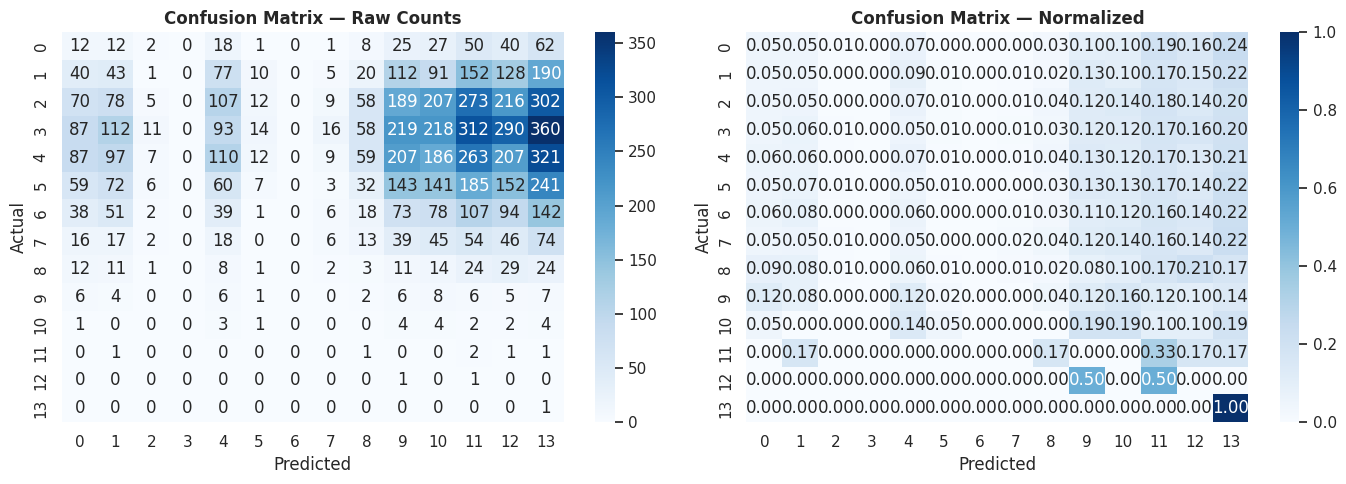


Top 10 Important Features:
                              Feature  Importance
                    patient_age_group    0.283771
                       patient_gender    0.233750
                condition_type_Asthma    0.202789
              seasonal_indicator_Fall    0.150746
hospital_name_Riyadh General Hospital    0.128943


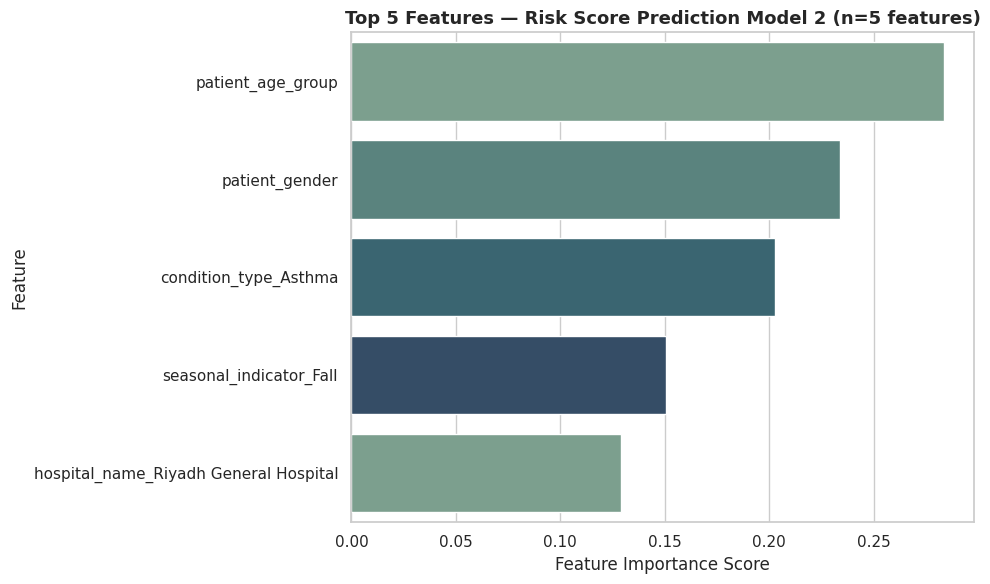

MODEL 2 PERFORMANCE INTERPRETATION

Target variable  : patient_risk_score (14 classes)
Best features    : 5
Best parameters  : {'gamma': 0, 'learning_rate': 0.02, 'max_depth': 4, 'n_estimators': 100, 'subsample': 0.6}
Final AUC (OvR)  : 0.5029
Log Loss         : 2.6043


In [41]:
custom_colors = ['#76a58e', '#538a83', '#316a7a', '#2d4d6e']

cm_2      = confusion_matrix(y_test_2, y_pred_2)
cm_norm_2 = confusion_matrix(y_test_2, y_pred_2, normalize='true')

tick_labels_2 = [str(c) for c in sorted(y_2.unique())]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm_2, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=tick_labels_2, yticklabels=tick_labels_2)
axes[0].set_title('Confusion Matrix — Raw Counts', fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

sns.heatmap(cm_norm_2, annot=True, fmt='.2f', cmap='Blues', ax=axes[1],
            xticklabels=tick_labels_2, yticklabels=tick_labels_2)
axes[1].set_title('Confusion Matrix — Normalized', fontweight='bold')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

# Feature importance
feature_importance_2 = pd.DataFrame({
    'Feature'   : X_best_train_2.columns,
    'Importance': final_model_2.feature_importances_
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

print('\nTop 10 Important Features:')
print(feature_importance_2.head(10).to_string(index=False))

n_bars       = min(10, len(feature_importance_2))
bar_colors_n = (custom_colors * 3)[:n_bars]

plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance_2.head(n_bars),
    x='Importance',
    y='Feature',
    hue='Feature',
    palette=bar_colors_n,
    legend=False
)
plt.title(f'Top {n_bars} Features — Risk Score Prediction Model 2 (n={best_n_2} features)',
          fontsize=13, fontweight='bold')
plt.xlabel('Feature Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# Interpretation
print('=' * 60)
print('MODEL 2 PERFORMANCE INTERPRETATION')
print('=' * 60)
print(f"""
Target variable  : patient_risk_score ({num_classes_2} classes)
Best features    : {best_n_2}
Best parameters  : {best_params_2}
Final AUC (OvR)  : {auc_final_2:.4f}
Log Loss         : {logloss_final_2:.4f}""")

###### 6.3.4 Save Results


In [42]:
# Export for Power BI
results_export_2 = X_best_test_2.copy()
results_export_2['actual']    = y_test_2.values
results_export_2['predicted'] = y_pred_2
results_export_2['correct']   = (results_export_2['actual'] == results_export_2['predicted']).astype(int)

for i, cls in enumerate(sorted(y_2.unique())):
    results_export_2[f'prob_score_{cls}'] = y_pred_prob_2[:, i].round(4)

results_export_2.to_csv('medisight_model2_predictions.csv', index=False)
print(f'Saved {len(results_export_2)} rows to medisight_model2_predictions.csv')

from google.colab import files
files.download('medisight_model2_predictions.csv')

Saved 8309 rows to medisight_model2_predictions.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>